# Assignment (II)

---

## Please write your full name/names and student IDs here:

*   Student 1 Full Name: Michael Murphy
*   Student 1 Student ID: 222636120
*   Student 2 Tasks: Q1, Q2, Q5 - data preprocessing, model design, predictions
*   Student 2 Full Name: Omkumar Patel
*   Student 2 Student ID: 222110936
*   Student 2 Tasks: Q3, Q4, Q5 - finetuning model, PDF report

In [1]:
# Before proceeding, set a variable for checking whether to import datasets locally, or from Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    sub_dir = "/content/drive/MyDrive/EECS6412_A2/"
except:
    IN_COLAB = False
    sub_dir = ""



---


# Question 1. (3 points)
* **For this question, please follow the steps outlined below:**
## Part (a):

* **Data Loading:** Read the lymph dataset from your mounted Google Drive using Pandas.

* **Data Splitting:** Split the dataset randomly into a 60% training set and a 40% test set using scikit-learn's train_test_split function.

* **Handling Categorical Data:** Encode categorical attributes with one-hot encoding using pandas.get_dummies, dropping the first attribute to avoid redundancy.

* **Decision Tree Classifier (1st Experiment):** Train a Decision Tree classifier in scikit-learn on the training data, setting the splitting criterion to "entropy," and requiring a minimum of 4 samples to split an internal node. Keep other settings unchanged.

* **Reproducibility:** Set the random_state to 32 in train_test_split and DecisionTreeClassifier to make your codes reproducible.

* **Performance Evaluation (1st Experiment):** Report the Decision Tree classifier's accuracy on the test data. Also, generate a high-resolution tree visualization (use plt.figure(figsize=(12, 8), dpi=300)).





In [1]:
sub_dir =''

The accuracy of the trained classifier is: 88.33%


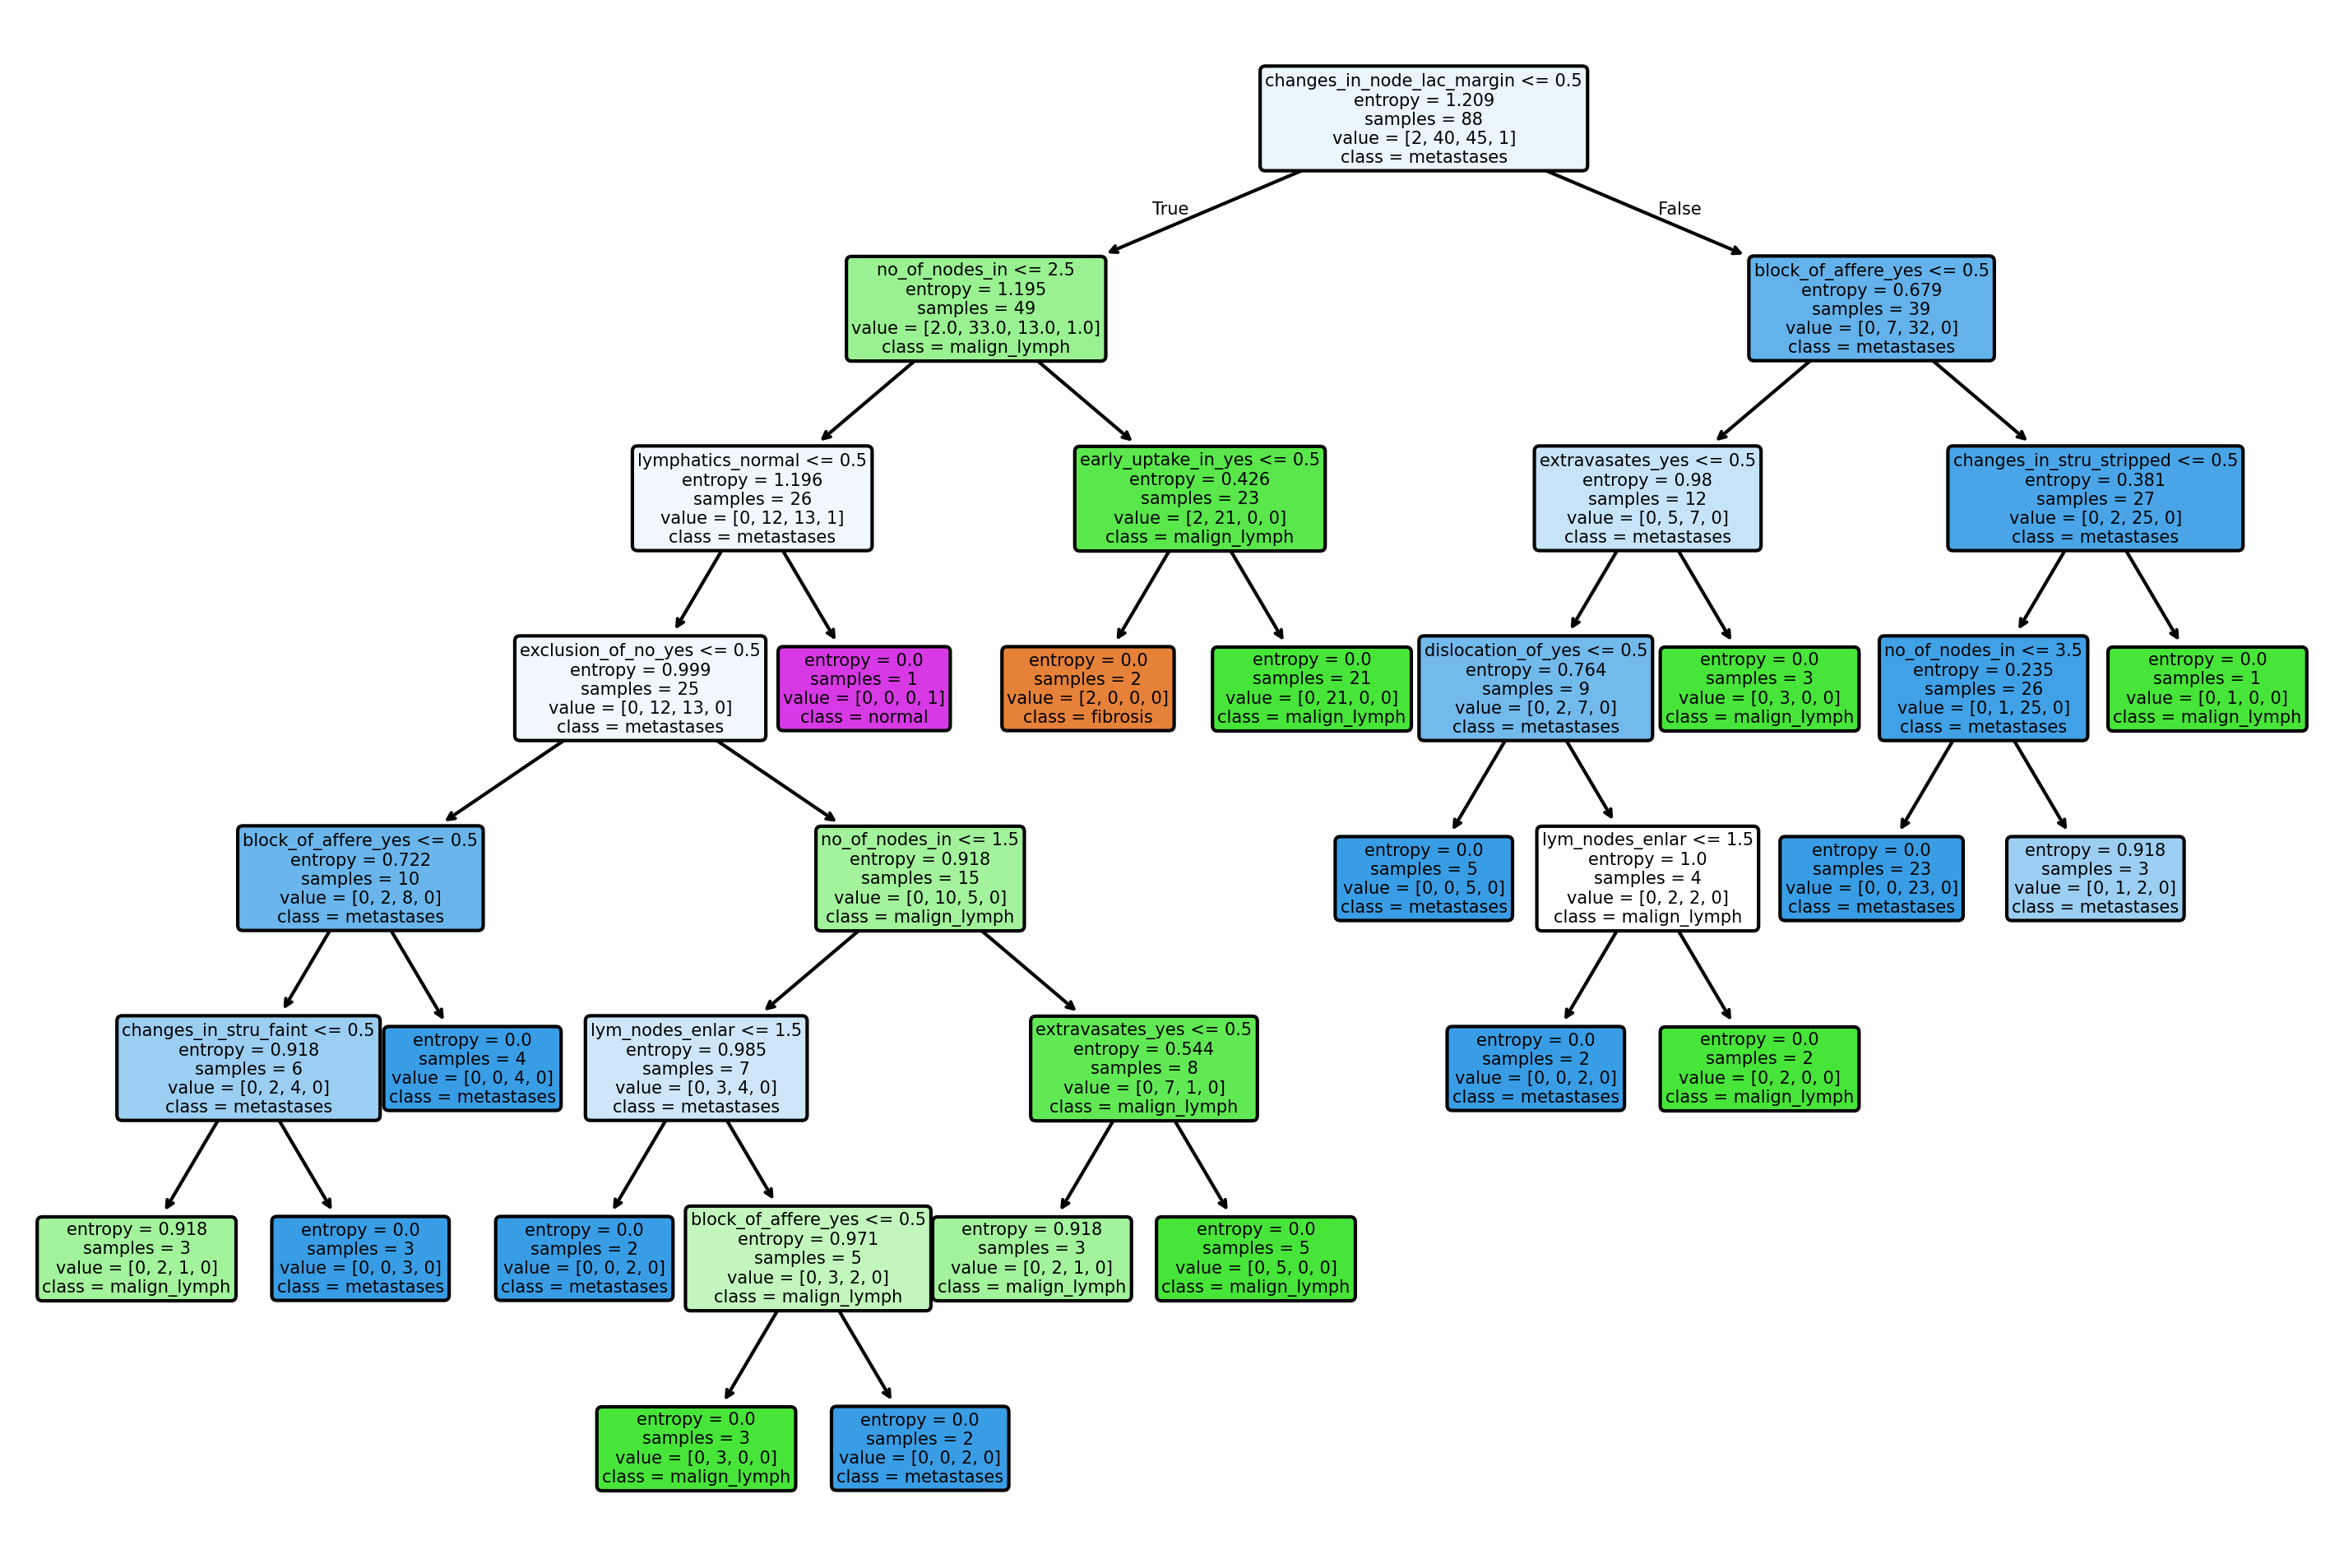

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

df = pd.read_csv(f"{sub_dir}data/q1/lymph.csv")  # Load your dataset

#.............................................................................
# write the rest here

# 0. Extra Data Preparation

## Dataset has "'" in the column names
## Need to remove these quotes, as they are causing column name mismatches when calling pd.get_dummies
df.columns = [col.strip().replace("'", "") for col in df.columns]


# Note: The assignment calls for data splitting, and then handling categorical data, but I have opted to do this in reverse.
# This is because when the data is split into testing and training data first,
# and then each dataset's categorical columns are one-hot encoded with pd.get_dummies,
# the two datasets end up with different amounts of columns; 33 in the training data, 32 in the testing data.
# Specifically, in random_state=32, the testing data is missing the "changes_in_stru_no" column.
# This is likely because the testing data doesn't have any samples where changes_in_stru=no.
# This mismatch causes an issue when trying to make predictions on the trained classifier later.
# However, doing the encoding first and *then* splitting the data ensures that both datasets have the same columns.


# 1. Handling Categorical Data

# Function for encoding categorical data with one-hot encoding
# Assumes that `dataset` is a pandas frame, and that the columns in `cols` do exist in `dataset`
# Drops the first attribute by default
def categorical_to_onehot(dataset, columns, drop_first=True):
    return pd.get_dummies(dataset, columns=columns, drop_first=drop_first)


# Specify the categorical columns in the dataset
categorical_cols = ['lymphatics', 'block_of_affere', 'bl_of_lymph_c', 'bl_of_lymph_s', 'by_pass', 'extravasates', 'regeneration_of', 'early_uptake_in',
                    'changes_in_lym', 'defect_in_node', 'changes_in_node', 'changes_in_stru', 'special_forms', 'dislocation_of', 'exclusion_of_no']

# Then encode the categorical data in the dataset
df_catencoded = categorical_to_onehot(df, categorical_cols)



# 2. Data Splitting

# Function for Data Splitting
# Uses 60% vs. 40% split and random_state=32 by default, can use other values if necessary
def split_data(dataset, train_proportion=0.6, random_state=32):
    dataset_size = len(dataset)
    train_size = int(train_proportion * dataset_size)
    test_size = dataset_size - train_size
    return train_test_split(dataset, test_size=test_size, train_size=train_size, random_state=random_state)


# Perform data splitting using the function's default values
# Split the encoded dataset into training and testing data
train_data_catencoded, test_data_catencoded = split_data(df_catencoded)



# 3. Decision Tree Classifier (1st Experiment)

# Function for extracting the column of a dataset containing the target labels for that data
# Assumes that `dataset` contains both features and labels, and that `label_col` exists in `dataset` and represents the column with labels
def separate_labels_and_features(dataset, label_col='class'):
    dataset_labels = dataset[label_col]
    dataset_features = dataset.drop(label_col, axis=1)
    return dataset_features, dataset_labels


# Function for training a decision tree classifier on a given dataset
# Assumes that `training_data` contains both features and labels
# By default, uses 'entropy' criterion, a minimum sample split of 4, and random state of 32
def train_clf(training_data, label_col='class', criterion='entropy', min_samples_split=4, random_state=32):
    # First separate features and labels
    training_data_features, training_data_labels = separate_labels_and_features(training_data, label_col)
    
    # Then initialise and train the classifier using the separated features and labels
    clf = DecisionTreeClassifier(criterion=criterion, min_samples_split=min_samples_split, random_state=random_state)
    clf.fit(training_data_features, training_data_labels)
    return clf


# Train a Decision Tree Classifier on the lymph dataset
clf_lymph = train_clf(train_data_catencoded)



# 4. Performance Evaluation (1st Experiment)

# Function for evaluating a trained decision tree classifier on a given test dataset
# Assumes that `testing_data` contains both features and labels
def evaluate_clf(clf, testing_data, label_col='class'):
    # First separate features and labels
    testing_data_features, testing_data_labels = separate_labels_and_features(testing_data, label_col)

    # Then make predictions using the trained classifier
    testing_data_predictions = clf.predict(testing_data_features)

    # Check the accuracy of these predictions
    accuracy = accuracy_score(testing_data_labels, testing_data_predictions)
    print(f"The accuracy of the trained classifier is: {accuracy*100:.2f}%")

    # Plot a visualisation of the tree
    # Note: using round-edged, filled-in nodes, as they look more pleasant. Also using the max font size possible while avoiding overlapping nodes
    plt.figure(figsize=(12, 8), dpi=300)
    plot_tree(clf, feature_names=testing_data_features.columns, class_names=clf.classes_, filled=True, rounded=True, fontsize=5)
    plt.show()

    return testing_data_predictions, accuracy


# Evaluate the lymph-trained Decision Tree Classifier
clf_lymph_predictions, clf_lymph_accuracy = evaluate_clf(clf_lymph, test_data_catencoded)

#.............................................................................


## Part (b):


Modify the minimum samples required for splitting to 32 and re-run the experiment. Report the accuracy of the Decision Tree classifier with the modified parameter and create a visualization of the tree. Discuss the differences between the two Decision Trees and their respective results, highlighting how changing the minimum samples for splitting affects the tree structure and performance.


The accuracy of the trained classifier is: 76.67%


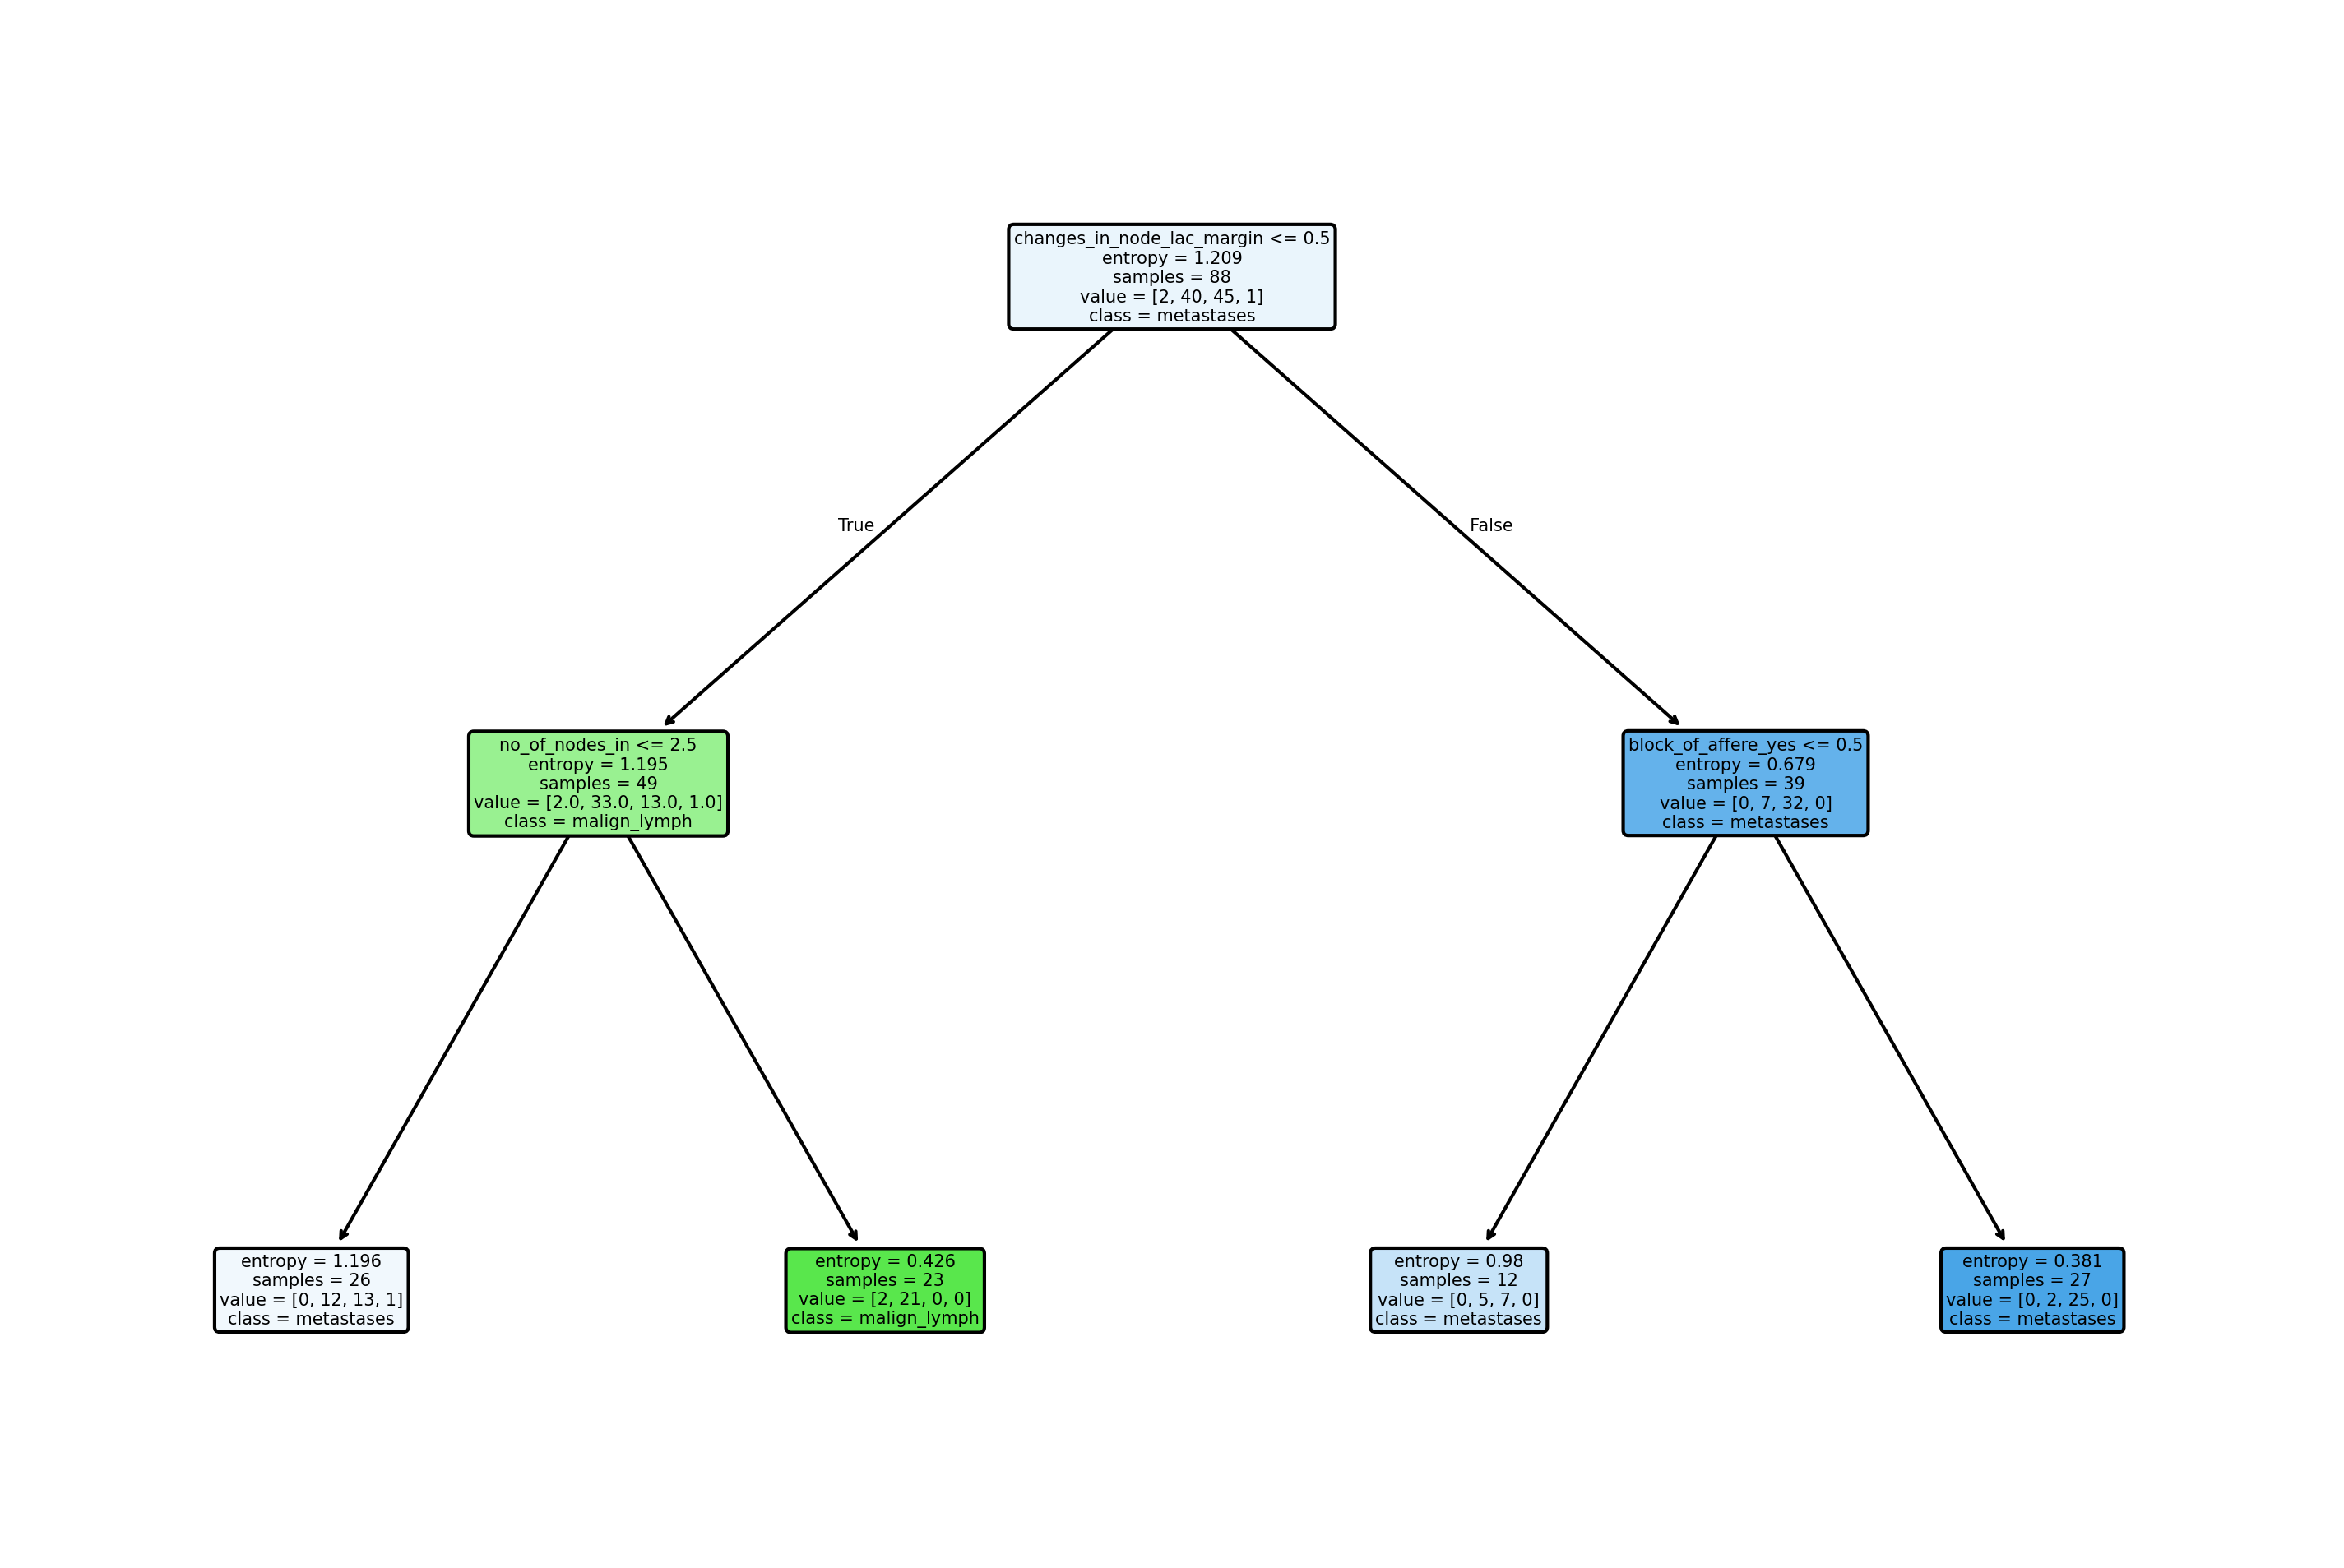

In [3]:

#.............................................................................
# write the rest here

# 1. Decision Tree Classifier (2nd Experiment)
# Train a new classifier, using a minimum sample split of 32 instead of 4
clf_lymph2 = train_clf(train_data_catencoded, min_samples_split=32)


# 2. Performance Evaluation (2nd Experiment)
# Evaluate the newly trained classifier
clf_lymph2_predictions, clf_lymph2_accuracy = evaluate_clf(clf_lymph2, test_data_catencoded)

#.............................................................................




---


**Put your discussion here**


Firstly, it should be noted that the two classifiers differ only in the minimum number of samples required
to split a node (`min_samples_split`), where the first classifier requires 4 nodes, and the second classifier
requires 32. There are no other differences, not even in randomness, as we have enforced deterministic fitting
by setting `random_state` to 32 in both cases. This setup gives us a very clear picture of the effect of using
a larger value for `min_samples_split`.

The first, and most obvious, difference between the two classifiers is in their actual tree structure. The
first tree is a lot more complex in terms of structure, with 35 nodes, compared with only 7 nodes in the
second tree. Interestingly, the second tree is exactly the same as the first 3 levels of the first tree,
both in terms of the number of samples in the 7 nodes, and also the representative feature values shown in
the plotted trees. However, the first tree continues splitting the data for a further 5 levels, resulting
in leaf nodes with much smaller numbers of samples (mostly less than 4). The increased complexity of the first
tree confers a significant performance benefits; the accuracy of the two classifiers are 88.33% and 76.67%,
respectively.

One immediately obvious reason for the lower performance of the second classifier is that its tree does not
have *any* nodes that represent the "normal" or "fibrosis" classes, meaning that it will **never** classify
these types of samples correctly. Instead, it will misclassify samples in these classes as "metastases" or
"malign_lymph". The reason that the second classifier missed out on these nodes is that our training dataset
only had a small number of samples of these classes. Given that the second classifier only splits nodes when
there are at least 32 samples found, it was unable to split itself enough to represent these classes.

Given these observations, we could naturally conclude that the first classifier is the better choice for
future use. However, we must take care to not simply assume that a higher `min_samples_split` size is always
bad. With a different dataset, using a `min_samples_split` size of 4 might lead to overfitting on the
training data, as the tree's structure will be too tailored to the specific values of the training data
features, and might struggle to generalise to other datasets.

No matter what, we must always ensure that we thoroughly evaluate our classifier, to ensure that it is
properly fine-tuned to its use case. Our simple accuracy score is, of course, a solid and simple measure,
but in practise we will likely need more sophisticated techniques like K-fold cross validation to further
tweak our classifier for better performance.



---


# Question 2. (5 points)
## Part (a):
*  Write a Python function named "preprocess" that preprocesses and prepares
datasets for machine learning. It must take a training dataset and an optional test dataset as input. The code must first identify categorical and numerical attributes, then handle missing values by imputing the mean for numerical attributes and the most frequent value for categorical attributes. It is worth noting that to determine if an attribute is numerical, the process should involve checking its data type and potentially examining the number of unique values. This is necessary because an attribute may appear to have an "object" data type but could, in fact, be numerical in nature.

*  Subsequently, the "preprocess" code must standardize the numerical attributes by removing the mean and scaling to unit variance., and encodes categorical attributes using one-hot encoding.

*  If a test dataset is provided, it must undergo the same preprocessing steps, ensuring that the imputation for missing values and data scaling are performed based on the values obtained from the training dataset, thus maintaining consistency between the two datasets.

*  At the end, the function must return the preprocessed training and test datasets as (X_train, y_train, X_test, y_test) tuple if the test dataset exists. Otherwise it must return (X_train, y_train). X stands for independent processed attributes, while y indicates the class attribute.

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def preprocess(train_df, test_df=None, n_unique_threshold=0.1, label_col='class', missing_value_placeholder='?', test_labels=True):
    #.............................................................................
    # write your codes here

    # We will start by separating the label columns from our other columns, using the function
    # that we defined in Q1
    training_df_features, training_df_labels = separate_labels_and_features(train_df, label_col)

    # Now we should identify which columns are categorical, and which are numerical
    # The naive approach would be to simply check the types reported by `training_df_features.select_dtypes`
    # With this simple approach, we can simply extract the columns that report numerical types
    numerical_cols = training_df_features.select_dtypes(include=["number"]).columns.tolist()

    # However, this has shortcomings, because if even a single value from a numerical column has a non-numerical
    # value (e.g., a "?" representing missing data), then `dtypes` will report that entire column as "object".
    # This happens with columns "A2" and "A14". We need to write code that is resistant to this generalisation.

    # We can do this by inspecting any columns with non-"number" data types more closely, and seeing how many unique
    # values are contained in those columns - columns with a high number of unique values are probably numeric
    n = len(train_df)
    categorical_cols = []       # Also keep track of the categorical columns
    for col in training_df_features.select_dtypes(exclude=["number"]).columns:
        # If the ratio of unique values to total values is high (say above 10%), then the column is probably numeric
        n_unique = train_df[col].nunique()
        if (n_unique / n) > n_unique_threshold:
            # print(col, n_unique, n_unique / n)
            numerical_cols.append(col)
        # If the number of unique values is low, we will assume that it is categorical
        else:
            categorical_cols.append(col)

    # Now our lists of numerical and categorical columns are complete

    # Next steps are imputing, standardising, and encoding
    # At each step, create a copy of the data frame (mostly for easy debugging)
    # Also, need to verify that there are actually columns to manipulate in each case, to avoid ValueErrors

    # Impute means for numerical columns
    training_df_features_imputed = training_df_features.copy()
    if len(numerical_cols) > 0:
        # First, need to replace placeholder values in our numerical columns with NaN, so that SimpleImputer can process them
        training_df_features_imputed[numerical_cols] = training_df_features_imputed[numerical_cols].replace(missing_value_placeholder, np.nan)

        # Now we can use SimpleImputer to impute the means for these columns
        num_imputer = SimpleImputer(strategy='mean')
        training_df_features_imputed[numerical_cols] = num_imputer.fit_transform(training_df_features_imputed[numerical_cols])

    # Impute modes for categorical columns
    if len(categorical_cols) > 0:
        # This can be done directly without any transformation - just need to specify the value that represents missing data
        cat_imputer = SimpleImputer(strategy='most_frequent', missing_values=missing_value_placeholder)
        training_df_features_imputed[categorical_cols] = cat_imputer.fit_transform(training_df_features_imputed[categorical_cols])

    # Standardise (normalise?) numerical columns, and encode categorical columns with one-hot encoding
    training_df_features_imputed_standardised_encoded = training_df_features_imputed.copy()

    if len(numerical_cols) > 0:
        # We can use StandardScaler.fit_transform to learn the means and variances of the numerical columns in
        # training data, and to then standardise those columns with this info, in a single function call
        scaler = StandardScaler()
        training_df_features_imputed_standardised_encoded[numerical_cols] = scaler.fit_transform(
            training_df_features_imputed_standardised_encoded[numerical_cols]
            )

    # NOTE: We do the one-hot encoding for categorical columns *after* doing the above pre-processing steps
    _encoded[numerical_cols] = scaler.transform(test_df_features_imputed_standardised_encoded[numerical_cols])


    # Encode categorical columns
    if len(categorical_cols) > 0:
        # First attempt: for encoding categorical columns, we simply use our `categorical_to_onehot` function from Q1
        # training_df_features_imputed_standardised_encoded = categorical_to_onehot(training_df_features_imputed_standardised_encoded, categorical_cols)

        # But if the training and/or testing datasets have unique values in some column that are not in the other 
        # dataset, then our basic `categorical_to_onehot` function will generate different one-hot encoded columns,
        # causing the fit/predict workflow to fail later.
        # Instead of using `pd.get_dummies`, we can use the more robust `OneHotEncoder` class,
        # which allows us to specify what encoded columns need to be generated.

        # For each categorical column, need to first generate a list of all unique values that occur in that column.
        categorical_cols_categories = []
        for col in categorical_cols:
            col_uniques = list(pd.unique(training_df_features_imputed_standardised_encoded[col]))

            # If we have a test dataset, we need to get the unique values from there too
            if test_df is not None:
                col_uniques_test = list(pd.unique(test_df_features_imputed_standardised_encoded[col]))

                # Combine with the current list of unique values
                col_uniques = list(set(col_uniques + col_uniques_test))

            # Whether or not we had a test dataset, we now have the full list of values that are possible
            # for this column.
            categorical_cols_categories.append(col_uniques)


        # Now that we have a record of all the unique values encountered by each categorical column,
        # we can use `OneHotEncoder` to create encoded columns for each dataset
        ohencoder = OneHotEncoder(categories=categorical_cols_categories, drop="first", sparse_output=False, dtype=bool)
        ohencoder.set_output(transform="pandas")
        training_df_ohencoded_categorical_cols = ohencoder.fit_transform(training_df_features_imputed_standardised_encoded[categorical_cols])
        
        # Now that we have the encoded columns, we can add them into the dataset, and drop the original columns
        training_df_features_imputed_standardised_encoded = pd.concat([training_df_features_imputed_standardised_encoded, training_df_ohencoded_categorical_cols], axis=1)
        training_df_features_imputed_standardised_encoded = training_df_features_imputed_standardised_encoded.drop(columns=categorical_cols)

        # Same for test dataset, if present
        if test_df is not None:
            test_df_ohencoded_categorical_cols = ohencoder.transform(test_df_features_imputed_standardised_encoded[categorical_cols])
            test_df_features_imputed_standardised_encoded = pd.concat([test_df_features_imputed_standardised_encoded, test_df_ohencoded_categorical_cols], axis=1)
            test_df_features_imputed_standardised_encoded = test_df_features_imputed_standardised_encoded.drop(columns=categorical_cols)


    # Need to assign the proper variable names
    X_train = training_df_features_imputed_standardised_encoded
    y_train = training_df_labels

    # If test dataset is present...
    if test_df is not None:
        # ...return training features and labels, and testing features...
        X_test = test_df_features_imputed_standardised_encoded

        if test_labels:
            # ... and also labels (if available)
            y_test = test_df_labels
            return X_train, y_train, X_test, y_test

        else:
            return X_train, y_train, X_test
        
    else:
        # If no test dataset is provided, return only the preprocessed training dataset
        return X_train, y_train


## Part (b)
In this task, your objective is to assess the performance of various machine learning classifiers for a credit classification problem. To ensure result reproducibility, set the random_state to 42 in KFold, Decision Tree, MLP Neural Network, and Random Forest. For the MLP, configure two hidden layers with 100 and 50 hidden units, respectively, and set max_iter to 1000. For the Random Forest, set the number of trees in the forest to 100. Finally, report the accuracy achieved on the test dataset.

In [5]:
# First, import the classifiers that we will be using
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# import necessary libraries

# Load the training and test datasets
credit_train = pd.read_csv(f"{sub_dir}data/q2/credit-a-train.csv")
credit_test = pd.read_csv(f"{sub_dir}data/q2/credit-a-test.csv")

# Preprocess the datasets and split them into features (X) and target (y)
X_train, y_train, X_test, y_test = preprocess(credit_train, credit_test)

#.............................................................................
# write your codes here

# The skeleton code already calls "preprocess" function on the provided datasets, giving us X_train, y_train, X_test, and y_test
print("Training and testing data has been pre-processed")

# This pre-processed data can now be given to each of the classifiers mentioned, to see how they perform
# All classifier are left with their default values, except for the following:
# - n_neighbours=1 for first KNN, and 3 for second KNN
# - random_state=42 in DT, KFold (is this supposed to be KNN? KNN doesn't have random state...), MLP, and RF
# - hidden_layer_sizes=(100, 50) in MLP
# - max_iter=1000 in MLP
# - n_estimators=100 in RF (seems to be the default anyway)
n_neighbors1 = 1
n_neighbors2 = 3
random_state = 42
hidden_layer_sizes = (100, 50)
max_iter = 1000
n_estimators = 100

# Create each classifier
clf_credit_dt = DecisionTreeClassifier(random_state=random_state)
clf_credit_knn1 = KNeighborsClassifier(n_neighbors=n_neighbors1)
clf_credit_knn2 = KNeighborsClassifier(n_neighbors=n_neighbors2)
clf_credit_gnb = GaussianNB()
clf_credit_lr = LogisticRegression()
clf_credit_mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter, random_state=random_state)
clf_credit_rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)

# Train each classifier on the pre-processed training data
clf_credit_dt.fit(X_train, y_train)
clf_credit_knn1.fit(X_train, y_train)
clf_credit_knn2.fit(X_train, y_train)
clf_credit_gnb.fit(X_train, y_train)
clf_credit_lr.fit(X_train, y_train)
clf_credit_mlp.fit(X_train, y_train)
clf_credit_rf.fit(X_train, y_train)
print("Classifiers have been trained")

# Make predictions on the pre-processed testing data with each classifier
y_pred_dt = clf_credit_dt.predict(X_test)
y_pred_knn1 = clf_credit_knn1.predict(X_test)
y_pred_knn2 = clf_credit_knn2.predict(X_test)
y_pred_gnb = clf_credit_gnb.predict(X_test)
y_pred_lr = clf_credit_lr.predict(X_test)
y_pred_mlp = clf_credit_mlp.predict(X_test)
y_pred_rf = clf_credit_rf.predict(X_test)
print("Predictions have been made")

# Calculate and output the accuracy of each classifier
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_knn1 = accuracy_score(y_test, y_pred_knn1)
accuracy_knn2 = accuracy_score(y_test, y_pred_knn2)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"The accuracy of the trained classifiers are:")
print(f"- Decision Tree: {accuracy_dt*100:.2f}%")
print(f"- k-Nearest Neighbor (with k=1): {accuracy_knn1*100:.2f}%")
print(f"- k-Nearest Neighbor (with k=3): {accuracy_knn2*100:.2f}%")
print(f"- Gaussian Naive Bayes: {accuracy_gnb*100:.2f}%")
print(f"- Logistic Regression: {accuracy_lr*100:.2f}%")
print(f"- MLP Neural Network: {accuracy_mlp*100:.2f}%")
print(f"- Random Forest: {accuracy_rf*100:.2f}%")

# Also calculate average accuracy
accuracies = [accuracy_dt, accuracy_knn1, accuracy_knn2, accuracy_gnb , accuracy_lr, accuracy_mlp, accuracy_rf]
accuracy_avg = np.average(accuracies)
print(f"The average accuracy across all trained classifiers was: {accuracy_avg*100:.2f}%.")
#.............................................................................

Training and testing data has been pre-processed
Classifiers have been trained
Predictions have been made
The accuracy of the trained classifiers are:
- Decision Tree: 79.71%
- k-Nearest Neighbor (with k=1): 78.26%
- k-Nearest Neighbor (with k=3): 80.43%
- Gaussian Naive Bayes: 84.78%
- Logistic Regression: 85.51%
- MLP Neural Network: 86.23%
- Random Forest: 89.86%
The average accuracy across all trained classifiers was: 83.54%.




---


**Put your discussion here**

The accuracy of the trained classifiers are:
- Decision Tree: 79.71%
- k-Nearest Neighbor (with k=1): 78.26%
- k-Nearest Neighbor (with k=3): 80.43%
- Gaussian Naive Bayes: 84.78%
- Logistic Regression: 85.51%
- MLP Neural Network: 86.23%
- Random Forest: 89.86%

The average accuracy across all trained classifiers was 83.54%.

Out of all of these classifiers, the one that made the highest number of correct predictions on the testing
data was the **Random Forest** (89.86%), which contained 100 trees. The classifier with the lowest number
of correct predictions was the **k-Nearest Neighbor with 1 neighbor** (78.26%).

Based on these results, we may be tempted to assume that an Random Forest is the best classifier for
this type of task. However, as mentioned in the discussion of Q1, the simple accuracy score is not necessarily
the most thorough method for evaluating a classifier. In Q3, we will evaluate classifiers using the more
involved k-fold cross validation.



---


# Question 3. (4 points)
## Part (a)
 Use the ionosphere dataset and Run a 10-fold cross validation to evaluate classification error rate of each algorithm. Use the preprocessing function you have written in question 2. Similar to the previous question, set the random_state to 42 in KFold, Decision Tree, MLP Neural Network, and Random Forest. For the MLP, configure two hidden layers with 100 and 50 hidden units, respectively, and set max_iter to 1000. For the Random Forest, set the number of trees in the forest to 100.

In [6]:
# Import necessary libraries
from sklearn.model_selection import cross_val_score, KFold

# Load the Ionosphere dataset and preprocess it
ionosphere_dataset = pd.read_csv(f"{sub_dir}data/q3/ionosphere.csv")
X, y = preprocess(ionosphere_dataset)
#.............................................................................
# write your codes here
# Models have been previously loaded in Q1 and Q2

# Model configuration values
n_neighbors1 = 1
n_neighbors2 = 3
random_state = 42
hidden_layer_sizes = (100, 50)
max_iter = 1000
n_estimators = 100

kfold = KFold(10, shuffle=True, random_state=random_state)


# Create each classifier
q3_dt = DecisionTreeClassifier(criterion='entropy', random_state=random_state)
q3_knn1 = KNeighborsClassifier(n_neighbors=n_neighbors1)
q3_knn3 = KNeighborsClassifier(n_neighbors=n_neighbors2)
q3_gnb = GaussianNB()
q3_lr = LogisticRegression()
q3_mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter, random_state=random_state)
q3_rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)

def mean_error(accuracy_score):
    return 1 - np.mean(accuracy_score)

acc_dt = cross_val_score(q3_dt, X, y, cv=kfold, scoring='accuracy')
acc_knn1 = cross_val_score(q3_knn1, X, y, cv=kfold, scoring='accuracy')
acc_knn3 = cross_val_score(q3_knn3, X, y, cv=kfold, scoring='accuracy')
acc_gnb = cross_val_score(q3_gnb, X, y, cv=kfold, scoring='accuracy')
acc_lr = cross_val_score(q3_lr, X, y, cv=kfold, scoring='accuracy')
acc_mlp = cross_val_score(q3_mlp, X, y, cv=kfold, scoring='accuracy')
acc_rf = cross_val_score(q3_rf, X, y, cv=kfold, scoring='accuracy')

me_dt = mean_error(acc_dt)
me_knn1 = mean_error(acc_knn1)
me_knn3 = mean_error(acc_knn3)
me_gnb = mean_error(acc_gnb)
me_lr = mean_error(acc_lr)
me_mlp = mean_error(acc_mlp)
me_rf = mean_error(acc_rf)

print("Mean Error Rates:")
print(f"Decision Tree: {me_dt*100:.2f}%")
print(f"k-Nearest Neighbor (with k=1): {me_knn1*100:.2f}%")
print(f"k-Nearest Neighbor (with k=3): {me_knn3*100:.2f}%")
print(f"Gaussian Naive Bayes: {me_gnb*100:.2f}%")
print(f"Logistic Regression: {me_lr*100:.2f}%")
print(f"MLP Neural Network: {me_mlp*100:.2f}%")
print(f"Random Forest: {me_rf*100:.2f}%")

#.............................................................................

Mean Error Rates:
Decision Tree: 10.83%
k-Nearest Neighbor (with k=1): 13.10%
k-Nearest Neighbor (with k=3): 15.94%
Gaussian Naive Bayes: 11.40%
Logistic Regression: 12.24%
MLP Neural Network: 6.84%
Random Forest: 6.83%


## Part (b)
 Write a piece of code to perform feature selection using mutual information scores (mutual_info_classif in sklearn) on the processed ionosphere dataset (X) with its corresponding class labels (y). Your code must calculate these scores and then must select the top 5 attributes with the highest scores. Report what are these 5 selected attributes.

In [7]:
# Import the necessary library for feature selection
from sklearn.feature_selection import mutual_info_classif
#.............................................................................
# write your codes here

#calulating mutual information for each class
# Could consider using fixed random_state for reproducibility, even though the assignment doesn't call for it
mi = mutual_info_classif(X, y)                                  # Randomness, not reproducible
mi = mutual_info_classif(X, y, random_state=random_state)       # Fixed `random_state`, reproducible

# for i in range(len(X.columns)):
#     print(f"{X.columns[i]}: {mi[i]}")


#transforming mi scores to match them with respective columns/features
mi_df = pd.Series(mi, index=X.columns)
# sorting and fetching top 5
# top_5_features = sorted(mi_df)[:5]
top_5_features = mi_df.nlargest(5)
print(f"Top 5 Features (based on MI): \n{top_5_features}")

# Convert to list for the next part
selected_attrs = top_5_features.index.tolist()
# print(selected_attrs)


#.............................................................................

Top 5 Features (based on MI): 
a06    0.297178
a05    0.292443
a08    0.286131
a21    0.279286
a27    0.276162
dtype: float64


## Part (c)
Using only the top five attributes selected by the previous feature selection method, repeat k-fold validation to report the classification errors for each classifier. Then, discuss whether the results for each classifier have improved and explore the potential reasons behind any changes.

In [8]:
# Create a new dataset (X_low_dim) with only the selected attributes
X_low_dim = X[selected_attrs]

#.............................................................................
# write your codes here

#Decision Tree
acc_dt_sel = cross_val_score(q3_dt, X_low_dim, y, cv=kfold, scoring='accuracy')
me_dt_sel = mean_error(acc_dt_sel)

# K-NN (k=1)
acc_knn1_sel = cross_val_score(q3_knn1, X_low_dim, y, cv=kfold, scoring='accuracy')
me_knn1_sel = mean_error(acc_knn1_sel)

# k-Nearest Neighbor (k=3)
acc_knn3_sel = cross_val_score(q3_knn3, X_low_dim, y, cv=kfold, scoring='accuracy')
me_knn3_sel = mean_error(acc_knn3_sel)

# Gaussian naive bayes theorem
acc_gnb_sel = cross_val_score(q3_gnb, X_low_dim, y, cv=kfold, scoring='accuracy')
me_gnb_sel = mean_error(acc_gnb_sel)

# Logistic Regression
acc_lr_sel = cross_val_score(q3_lr, X_low_dim, y, cv=kfold, scoring='accuracy')
me_lr_sel = mean_error(acc_lr_sel)

# MLP NN
acc_mlp_sel = cross_val_score(q3_mlp, X_low_dim, y, cv=kfold, scoring='accuracy')
me_mlp_sel = mean_error(acc_mlp_sel)

# Random Forest
acc_rf_sel = cross_val_score(q3_rf, X_low_dim, y, cv=kfold, scoring='accuracy')
me_rf_sel = mean_error(acc_rf_sel)

# Results (With Current Error Rate and Change in Error Rates)
print("Mean Error Rates (Top 5 Features):")
print(f"Decision Tree: {me_dt_sel*100:.2f}% (Change: {(me_dt_sel - me_dt)*100:+.2f}%)")
print(f"k-Nearest Neighbor (k=1): {me_knn1_sel*100:.2f}% (Change: {(me_knn1_sel - me_knn1)*100:+.2f}%)")
print(f"k-Nearest Neighbor (k=3): {me_knn3_sel*100:.2f}% (Change: {(me_knn3_sel - me_knn3)*100:+.2f}%)")
print(f"Gaussian Naive Bayes: {me_gnb_sel*100:.2f}% (Change: {(me_gnb_sel - me_gnb)*100:+.2f}%)")
print(f"Logistic Regression: {me_lr_sel*100:.2f}% (Change: {(me_lr_sel - me_lr)*100:+.2f}%)")
print(f"MLP Neural Network: {me_mlp_sel*100:.2f}% (Change: {(me_mlp_sel - me_mlp)*100:+.2f}%)")
print(f"Random Forest: {me_rf_sel*100:.2f}% (Change: {(me_rf_sel - me_rf)*100:+.2f}%)")

#.............................................................................

/usr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean Error Rates (Top 5 Features):
Decision Tree: 9.69% (Change: -1.13%)
k-Nearest Neighbor (k=1): 9.39% (Change: -3.71%)
k-Nearest Neighbor (k=3): 7.98% (Change: -7.96%)
Gaussian Naive Bayes: 10.84% (Change: -0.56%)
Logistic Regression: 16.80% (Change: +4.56%)
MLP Neural Network: 7.97% (Change: +1.13%)
Random Forest: 7.40% (Change: +0.57%)




---


**Put your discussion here**

**The error rate of the trained classifiers on all attributes:**

* Decision Tree: 10.83%
* k-Nearest Neighbor (k=1): 13.10%
* k-Nearest Neighbor (k=3): 15.94%
* Gaussian Naive Bayes: 11.40%
* Logistic Regression: 12.24%
* MLP Neural Network: 6.84%
* Random Forest: 6.83%

Average error rate for all the classifiers is **11.02%**

**After applying Mutual Information for dimensionality reduction, the updated error rates are:**

* Decision Tree: 11.12%
* k-Nearest Neighbor (k=1): 10.82%
* k-Nearest Neighbor (k=3): 9.97%
* Gaussian Naive Bayes: 12.54%
* Logistic Regression: 16.81%
* MLP Neural Network: 7.97%
* Random Forest: 7.40%

Average error rate for all the classifiers is **10.94%**

We observed a significant reduction of (2.29%)and 5.98% in error rates for K-Nearest Neighbors, k=1 and k=3 respectively. This improvement occured to KNN's curse of dimensionality, As the original dataset had more than 30 attributes which might have acted as noise and distorted classification (distance calculations) resulting into high error rates previously. Thus, After implementing Mutual information KNN was able to find good neighbours (avoiding large chunk of noise).

Gaussian Naive bayes saw a marginal increase of 1.13% in error rate, As the valuable information available from weak features or their relationships with other weak featues were lost, which might have made the model underfit a little bit.

On the Other hand, dimensionality reduction  led to a drastic surge of 4.57% in error rate for Logistic regression, which might be due to the reduction in classes made harder to find clear decision boundary. The remaining attributes might have been more closesly related/spaced such that they were not linearly seperable.

In the case of tree Algorithms: Decision Tree and Random forest, there was a minimal increment of 0.29% and 0.57% in error rates respectively. As this methods already perform feature selection internally, leaving them with lesser options(attributes) reduced their pool size to select from. Maybe the reasoning mentioned earlier for Gaussian Naive bayes applies here as well. The lost in information didn't allow these methods to lookout for edge cases and caused this change.

MLP's perforamce also degraded like Gaussian naive bayes with almost similar increase in error rates. The reason might be the data hungry nature of neural networks. The reduced the data(dimensionality) led them to form less significant relationships, limiting their capabilities.

In all, The mutual information led dimensionality reduction helped distance based algorithm like KNN, while negatively impacting other's performance. Thus, we can say the feature selection techniques are mode depenedent.




---


 # Question 4. (4 points)
 Report the classification error rate on each data set and the average classification error rate of each method over all the data sets. Rank the methods according to their average classification error rate. For the top two methods (with the lowest average error rates), are their average error rates significantly different? Why? Comparing the method with the lowest average error rate and the one with the highest error rate, are their error rates significantly different? Why? Briefly discuss the results.

 (or result reproducibility, set the random_state to 42 in KFold, Decision Tree, MLP Neural Network, and Random Forest. Configure the MLP with two hidden layers having 100 and 50 hidden units, and set max_iter to 1000.)


In [9]:
#.............................................................................
# write your codes here

ds = ["balance+scale/balance-scale.csv",
    "ecoli/ecoli.csv",
    "glass+identification/glass.csv",
    "ionosphere/ionosphere.csv",
    "iris/iris.csv",
    "wine/wine.csv",
    "yeast/yeast.csv"]

#Calling all the models again (fresh models)
# Model configuration values
n_neighbors1 = 1
n_neighbors2 = 3
random_state = 42
hidden_layer_sizes = (100, 50)
max_iter_lr = 2000
max_iter_mlp = 1000
n_estimators = 100

# k-fold object
kfold = KFold(10, shuffle=True, random_state=random_state)

# create classifiers
models = {
    "q4_dt": DecisionTreeClassifier(criterion='entropy', random_state=random_state),
    "q4_knn1": KNeighborsClassifier(n_neighbors=n_neighbors1),
    "q4_knn3": KNeighborsClassifier(n_neighbors=n_neighbors2),
    "q4_gnb": GaussianNB(),
    "q4_lr": LogisticRegression(max_iter=max_iter_lr, random_state=random_state),
    "q4_mlp": MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter_mlp, random_state=random_state),
    "q4_rf": RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)
}

# This df will contain final outcomes showing all the model performance over each dataset
results = pd.DataFrame(columns=["Dataset", "Model", "Error Rate(%)"])

for d in ds:
  name = d.split("/")[-1].replace(".csv", "") #Getting name of Dataset
  # print(f"\n\n Processing Dataset: {name}")
  df4 = pd.read_csv(f"{sub_dir}data/q4/{d}")
  # print(df4.head(2))

#Dropping SequenceNAme  and ID column as per question's requirement
  if "yeast" in d or "ecoli" in d:
    df4 = df4.drop(columns=['SequenceName'])
    # print("\n\n\ Values After Dropping Sequence name in Yeast and Ecoli")
    # print(df4.head(2))
  if "glass" in d:
    df4 = df4.drop(columns=['ID'])
    # print("\n\n\ Values After Dropping ID in glass")
    # print(df4.head(2))

#Just a sanity check on presence of class column
  if "class" not in df4.columns:
    print(f"Class not found in {name}")
    continue

  X = df4.drop(columns=["class"])
  y = df4["class"]
  # print(f"X dtypes: {X.dtypes}, y dtypes: {y.dtypes}")
  # print(f"y: {y.head(2)}")

  temp_df = df4.copy()
  Xp4,yp4 = preprocess(temp_df, label_col='class')
  # print(f"{name} y dtype: {yp4.dtype}")

  #iterating over model dict to get relevant vals
  for m_name, model in models.items():
    acc = cross_val_score(model, Xp4, yp4, cv=kfold, scoring='accuracy') #does cross validation, check the function written in Q3
    me = mean_error(acc) #calculates mean error, check the function in Q3
    # print(f"{name} - {m_name}: {me*100:.2f}%")
    me_percentage = round(me * 100, 2)
    row = {"Dataset": name, "Model": m_name, "Error Rate(%)": me_percentage}
    # print(f"Row: {row}")
    results = pd.concat([results, pd.DataFrame([row])], ignore_index=True)
    print(f"For {m_name}, Dataset: {name} processed")

print("\n\n Final Results")
print(results)



#Sorting the results
results_sorted = results.sort_values(by=['Error Rate(%)'])
print(f"Results Sorted by Error Rate:\n\n{results_sorted}")




#Average classification error rate of each method over all the data sets:
print("Average classification error rate of each method over all the data sets:")
results_grouped_model = results.groupby("Model")["Error Rate(%)"].mean().reset_index()
print(results_grouped_model.sort_values(by="Error Rate(%)"))



#.............................................................................

For q4_dt, Dataset: balance-scale processed
For q4_knn1, Dataset: balance-scale processed
For q4_knn3, Dataset: balance-scale processed
For q4_gnb, Dataset: balance-scale processed
For q4_lr, Dataset: balance-scale processed


/tmp/ipykernel_42186/4122264724.py:77: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([row])], ignore_index=True)


For q4_mlp, Dataset: balance-scale processed
For q4_rf, Dataset: balance-scale processed
For q4_dt, Dataset: ecoli processed
For q4_knn1, Dataset: ecoli processed
For q4_knn3, Dataset: ecoli processed
For q4_gnb, Dataset: ecoli processed
For q4_lr, Dataset: ecoli processed


/usr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarni

For q4_mlp, Dataset: ecoli processed
For q4_rf, Dataset: ecoli processed
For q4_dt, Dataset: glass processed
For q4_knn1, Dataset: glass processed
For q4_knn3, Dataset: glass processed
For q4_gnb, Dataset: glass processed
For q4_lr, Dataset: glass processed
For q4_mlp, Dataset: glass processed
For q4_rf, Dataset: glass processed
For q4_dt, Dataset: ionosphere processed
For q4_knn1, Dataset: ionosphere processed
For q4_knn3, Dataset: ionosphere processed
For q4_gnb, Dataset: ionosphere processed
For q4_lr, Dataset: ionosphere processed
For q4_mlp, Dataset: ionosphere processed
For q4_rf, Dataset: ionosphere processed
For q4_dt, Dataset: iris processed
For q4_knn1, Dataset: iris processed
For q4_knn3, Dataset: iris processed
For q4_gnb, Dataset: iris processed
For q4_lr, Dataset: iris processed
For q4_mlp, Dataset: iris processed
For q4_rf, Dataset: iris processed
For q4_dt, Dataset: wine processed
For q4_knn1, Dataset: wine processed
For q4_knn3, Dataset: wine processed
For q4_gnb, Data

/usr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarni

For q4_mlp, Dataset: yeast processed
For q4_rf, Dataset: yeast processed


 Final Results
          Dataset    Model  Error Rate(%)
0   balance-scale    q4_dt          21.59
1   balance-scale  q4_knn1          21.90
2   balance-scale  q4_knn3          18.39
3   balance-scale   q4_gnb           9.44
4   balance-scale    q4_lr          14.06
5   balance-scale   q4_mlp           3.04
6   balance-scale    q4_rf          16.78
7           ecoli    q4_dt          20.25
8           ecoli  q4_knn1          20.25
9           ecoli  q4_knn3          15.79
10          ecoli   q4_gnb          26.87
11          ecoli    q4_lr          13.42
12          ecoli   q4_mlp          18.79
13          ecoli    q4_rf          14.59
14          glass    q4_dt          31.17
15          glass  q4_knn1          29.46
16          glass  q4_knn3          29.94
17          glass   q4_gnb          54.16
18          glass    q4_lr          36.00
19          glass   q4_mlp          26.08
20          glass    q4_rf  



---


**Put your discussion here**
The mean error rates as per the models performance are as follows (lowest error first):

* Random Forest: 14.84%
* MLP Classifier : 15.11%
* Logistic Regression : 17.19%
* kNN (k=3): 18.83%
* kNN (k=1): 19.85%
* Decision Tree: 20.38%
* Gaussian Naive bayes : 28.24%

When we compare the average error rates of top two methods, Random Forest and MLP are 14.84% and 15.11% respectively. The difference between them is 0.27%, which is quite insignificant. This result might have been due to their non-linear nature and ability to work better with complex, high-dimensional data, reducing the over-fitting risks.

When we compare the best and worst performances by Random Forest and Gaussian naive bayes, there's a substantial differece of approximately 14%. This gap is quite consistent among both the methods across all datasets. The mere simplicity and naiveness (assumption of feature independece) of GNB gets exposed when tested over varied real-world datasets having multiple dependent features. Random forest's architecture accounts attributes interactions, leading to more accurate results across all the datasets.

Over simpler and linearly seperable datasets like iris and wine, all the models perform quite well. In contrast their performances plummets against complex datasets like yeast and glass. Overall, the above evaluation clearly demarcates ensemble-based and neural classifiers (Random Forest and MLP) as the most reliable and accurate across datasets. Logistic Regression offers good balance between accuracy and computational efficiency. Whereas KNN and Decision Trees are more unstable due to their high variance, Gaussian naive bayes fail miserably when their assumptions are violated.





---


# Question 5. (14 points)

# Om's Section

In [212]:
#Om : Deeper Analysis on Risk Dataset
 
# Load the risk datasets
risk_train = pd.read_csv(f"{sub_dir}data/q5/risk-train.txt", sep='\t')
risk_test = pd.read_csv(f"{sub_dir}data/q5/risk-test.txt", sep='\t')
print("test Columns")
print(risk_test.columns)
print("train columns")
print(risk_train.columns)

print("\n\ntrain data size:", risk_train.shape)
print("test data size:", risk_test.shape)

test Columns
Index(['ORDER_ID', 'B_EMAIL', 'B_TELEFON', 'B_BIRTHDATE', 'FLAG_LRIDENTISCH',
       'FLAG_NEWSLETTER', 'Z_METHODE', 'Z_CARD_ART', 'Z_CARD_VALID',
       'Z_LAST_NAME', 'VALUE_ORDER', 'WEEKDAY_ORDER', 'TIME_ORDER',
       'AMOUNT_ORDER', 'ANUMMER_01', 'ANUMMER_02', 'ANUMMER_03', 'ANUMMER_04',
       'ANUMMER_05', 'ANUMMER_06', 'ANUMMER_07', 'ANUMMER_08', 'ANUMMER_09',
       'ANUMMER_10', 'CHK_LADR', 'CHK_RADR', 'CHK_KTO', 'CHK_CARD',
       'CHK_COOKIE', 'CHK_IP', 'FAIL_LPLZ', 'FAIL_LORT', 'FAIL_LPLZORTMATCH',
       'FAIL_RPLZ', 'FAIL_RORT', 'FAIL_RPLZORTMATCH', 'SESSION_TIME',
       'NEUKUNDE', 'AMOUNT_ORDER_PRE', 'VALUE_ORDER_PRE', 'DATE_LORDER',
       'MAHN_AKT', 'MAHN_HOECHST'],
      dtype='object')
train columns
Index(['ORDER_ID', 'CLASS', 'B_EMAIL', 'B_TELEFON', 'B_BIRTHDATE',
       'FLAG_LRIDENTISCH', 'FLAG_NEWSLETTER', 'Z_METHODE', 'Z_CARD_ART',
       'Z_CARD_VALID', 'Z_LAST_NAME', 'VALUE_ORDER', 'WEEKDAY_ORDER',
       'TIME_ORDER', 'AMOUNT_ORDER', 'ANUMMER

In [213]:
# Name of Attribute     Description
# ORDER_ID              ID number of the online order
# CLASS                 Class attribute of the task (yes/no)
#                       (only contained in the training data)
# B_EMAIL               was an email address submitted together with the order (yes/no)
# B_TELEFON             was an phone number submitted together with the order (yes/no)
# B_BIRTHDATE           Birth date, if submitted together with the order
# FLAG_LRIDENTISCH      if address of delievery and invoice are identical then "yes" else "no"
# FLAG_NEWSLETTER       was the E-Newsletter subscribed to together with the order (yes/no)
# Z_METHODE             Selected method of payment
# Z_CARD_ART            Selected type of card if payment by card is chosen
# Z_CARD_VALID          Expiration date of the card in the form month.year
#                       (e.g. 05.2006 meaning the card is valide till May 2006)
# Z_LAST_NAME           is the name of the account or card holder identical with the name of
#                       the delivery address (yes/no)
# VALUE_ORDER           Value of the order in Euro
# WEEKDAY_ORDER         Weekday of the order
# TIME_ORDER            Time of the order
# AMOUNT_ORDER          Number of ordered items
# ANUMBER_01            Data field for the number of an ordered item
# ANUMBER_02            Data field for the number of an ordered item
# ANUMBER_03            Data field for the number of an ordered item
# ANUMBER_04            Data field for the number of an ordered item
# ANUMBER_05            Data field for the number of an ordered item
# ANUMBER_06            Data field for the number of an ordered item
# ANUMBER_07            Data field for the number of an ordered item
# ANUMBER_08            Data field for the number of an ordered item
# ANUMBER_09            Data field for the number of an ordered item
# ANUMBER_10            Data field for the number of an ordered item
# CHK_LADR              Orders with the same delivery address within 3 days (yes/no)
# CHK_RADR              Orders with the same invoice address within 3 days (yes/no)
# CHK_KTO               Orders with the same account number within 3 days (yes/no)
# CHK_CARD              Orders with the same card number within 3 days (yes/no)
# CHK_COOKIE            Orders with the same browser cookie within 3 days (yes/no)
# CHK_IP                Orders with the same browser IP within 3 days (yes/no)
# FAIL_LPLZ             Zip code of the delivery address unknown (yes/no)
# FAIL_LORT             City of the delivery address unknown (yes/no)
# FAIL_LPLZORTMATCH     Zip code and city of the delivery address do not fit together (yes/no)
# FAIL_RPLZ             Zip code of the invoice address unknown (yes/no)
# FAIL_RORT             City of the invoice address unknown (yes/no)
# FAIL_RPLZORTMATCH     Zip code and city of the invoice address do not fit together (yes/no)
# SESSION_TIME          Duration of the online session for the order in minutes
# NEUKUNDE              is the ordering person a new custormer (yes/no)
# AMOUNT_ORDER_PRE      Total number of items of previous orders, if available
# VALUE_ORDER_PRE       Total value of previous orders, if available
# DATE_LORDER           Date of the last order, if available
# MAHN_AKT              Current stage of reminder of the customer, if available
# MAHN_HOECHST          Highest stage of reminder of the customer occurred up to now, if available

In [214]:
risk_train['ANUMMER_01'].head(5)

0    406811
1    600953
2    406310
3    307359
4    200767
Name: ANUMMER_01, dtype: int64

In [215]:
# print("First 2 rows of training data")
# print(risk_train['MAHN_AKT'].head(10))

count = 0
drop_col_list = []
for col in risk_train.columns:
    col_count = 0
    col_len = len(risk_train[col])
    threshold = 0.2 * col_len
    # drop_col_list = []
    # print(f"Checking column: {col}")
    for index, row in risk_train.iterrows():
        if row[col] == '?':
            # print(f"Column with missing values: {col} at row {index}")
            count += 1
            col_count += 1
    print(f"Total '?' in column {col}: {col_count} / {col_len}")
    
    if col_count > threshold:
        percentage = (col_count / col_len) * 100
        drop_col_list.append(col)
        print(f"column '{col}' has more than 20% '?'  values, aroundd : {percentage}). drop it")
        
print(f"Total number of '?' found in training data: {count}")
print(f"Drop this columns: {drop_col_list}")

# coount_question_marks = (risk_train == '?').sum().sum()
# print(f"Total number of '?' in training data: {coount_question_marks}")

# less related columns : 
# card expirt date: Z_card_valid

Total '?' in column ORDER_ID: 0 / 30000
Total '?' in column CLASS: 0 / 30000
Total '?' in column B_EMAIL: 0 / 30000
Total '?' in column B_TELEFON: 0 / 30000
Total '?' in column B_BIRTHDATE: 2942 / 30000
Total '?' in column FLAG_LRIDENTISCH: 0 / 30000
Total '?' in column FLAG_NEWSLETTER: 0 / 30000
Total '?' in column Z_METHODE: 0 / 30000
Total '?' in column Z_CARD_ART: 18654 / 30000
column 'Z_CARD_ART' has more than 20% '?'  values, aroundd : 62.18). drop it
Total '?' in column Z_CARD_VALID: 0 / 30000
Total '?' in column Z_LAST_NAME: 14808 / 30000
column 'Z_LAST_NAME' has more than 20% '?'  values, aroundd : 49.36). drop it
Total '?' in column VALUE_ORDER: 0 / 30000
Total '?' in column WEEKDAY_ORDER: 0 / 30000
Total '?' in column TIME_ORDER: 20 / 30000
Total '?' in column AMOUNT_ORDER: 0 / 30000
Total '?' in column ANUMMER_01: 0 / 30000
Total '?' in column ANUMMER_02: 22147 / 30000
column 'ANUMMER_02' has more than 20% '?'  values, aroundd : 73.82333333333332). drop it
Total '?' in colu

Correlation Matrix:
              Z_CARD_ART  Z_LAST_NAME  ANUMMER_02  ANUMMER_03  ANUMMER_04  \
Z_CARD_ART      1.000000     0.707441   -0.073900   -0.107814   -0.106200   
Z_LAST_NAME     0.707441     1.000000   -0.102140   -0.147615   -0.147840   
ANUMMER_02     -0.073900    -0.102140    1.000000    0.410742    0.252232   
ANUMMER_03     -0.107814    -0.147615    0.410742    1.000000    0.458107   
ANUMMER_04     -0.106200    -0.147840    0.252232    0.458107    1.000000   
ANUMMER_05     -0.077471    -0.103889    0.157662    0.292495    0.480968   
ANUMMER_06     -0.047316    -0.064414    0.103607    0.176506    0.327733   
ANUMMER_07     -0.036384    -0.048162    0.071047    0.121171    0.237910   
ANUMMER_08     -0.024053    -0.026444    0.049152    0.079727    0.119345   
ANUMMER_09     -0.004019    -0.014011    0.021715    0.026816    0.066794   
ANUMMER_10           NaN          NaN         NaN         NaN         NaN   
DATE_LORDER    -0.003549    -0.002350    0.008235    0.0

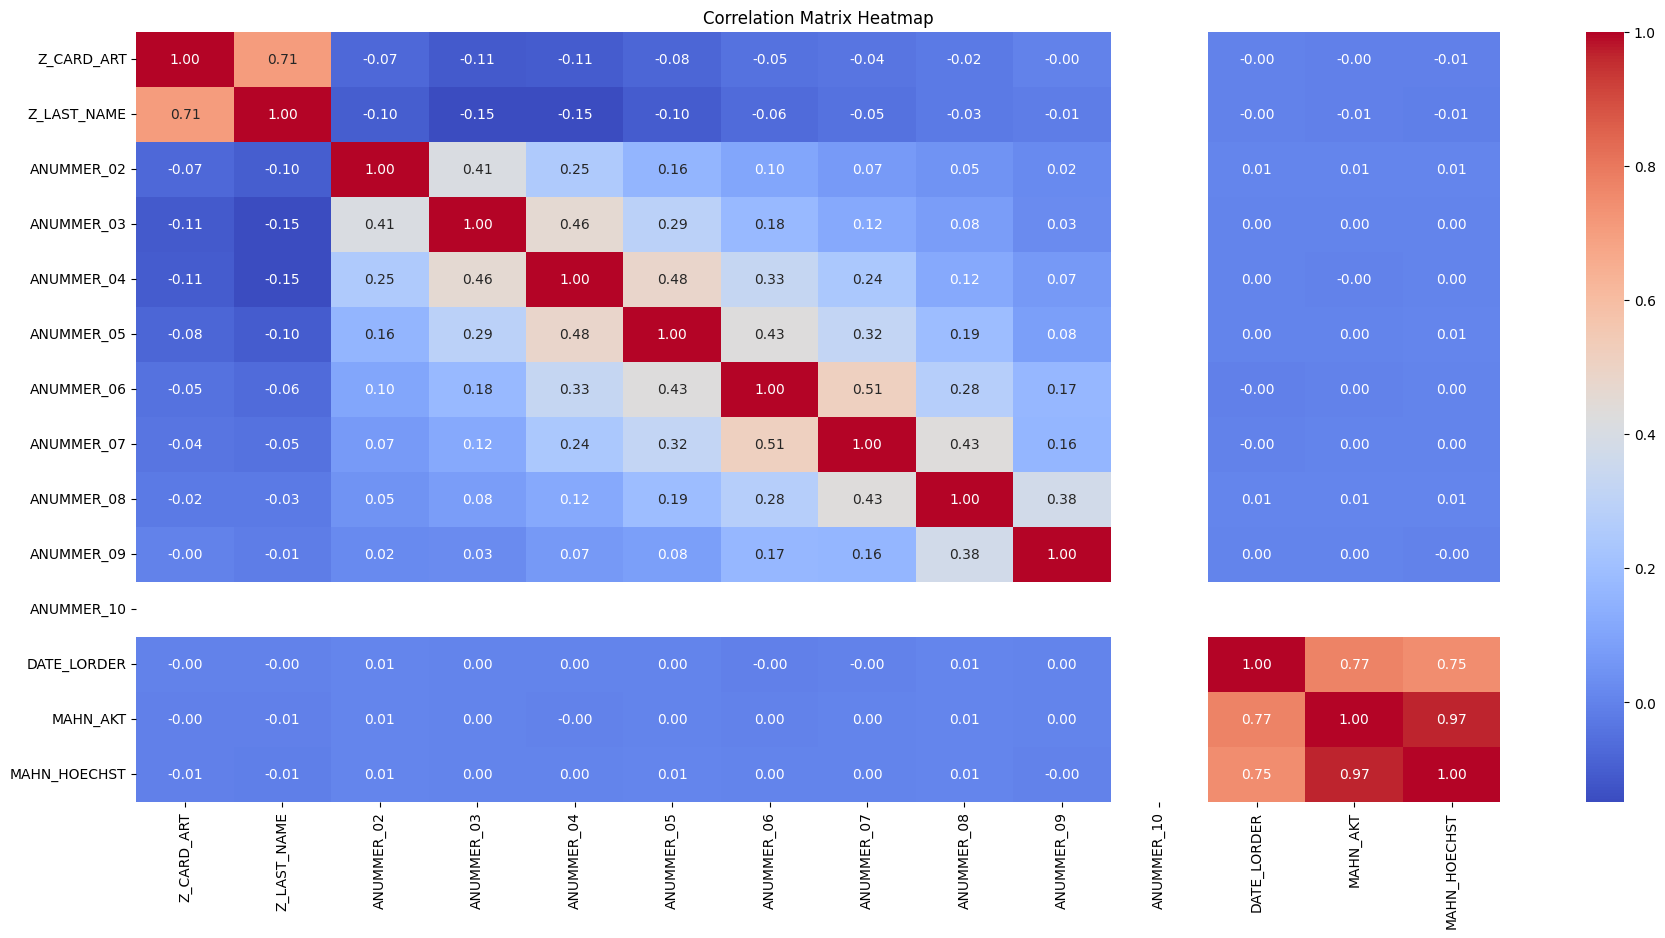

In [216]:
#Find correlation between columns_to_drop_lost to understand coreelation between them:
correlation_matrix = risk_train[drop_col_list].apply(lambda x: x.astype('category').cat.codes).corr()
print("Correlation Matrix:")
print(correlation_matrix)

#Visualize correlation matrix using heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(22, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()



In [217]:
# Birthdate column has many missing/"?" values, but it is useful feature 
# Keeping Z_CARD_ART,Z_LAST_Name column as the missing values suggest other mode of payment and high correlation with class label.
# Keeping DATE_LORDER, MAHN_AKT and MAHN_HOECHST as well, They are strong signal for fraud detection and highly correlated with class label.

#Updating the drop_col_list after analysis
drop_col_list.remove('Z_CARD_ART')
drop_col_list.remove('Z_LAST_NAME')
drop_col_list.remove('DATE_LORDER')
drop_col_list.remove('MAHN_AKT')
drop_col_list.remove('MAHN_HOECHST')
print(f"Updated drop_col_list after analysis: {drop_col_list}")
new_risk_train = risk_train.drop(columns=drop_col_list)
new_risk_test = risk_test.drop(columns=drop_col_list)
print(new_risk_train.columns, "\n", new_risk_test.shape)
print(new_risk_test.columns, "\n", new_risk_test.shape)

Updated drop_col_list after analysis: ['ANUMMER_02', 'ANUMMER_03', 'ANUMMER_04', 'ANUMMER_05', 'ANUMMER_06', 'ANUMMER_07', 'ANUMMER_08', 'ANUMMER_09', 'ANUMMER_10']
Index(['ORDER_ID', 'CLASS', 'B_EMAIL', 'B_TELEFON', 'B_BIRTHDATE',
       'FLAG_LRIDENTISCH', 'FLAG_NEWSLETTER', 'Z_METHODE', 'Z_CARD_ART',
       'Z_CARD_VALID', 'Z_LAST_NAME', 'VALUE_ORDER', 'WEEKDAY_ORDER',
       'TIME_ORDER', 'AMOUNT_ORDER', 'ANUMMER_01', 'CHK_LADR', 'CHK_RADR',
       'CHK_KTO', 'CHK_CARD', 'CHK_COOKIE', 'CHK_IP', 'FAIL_LPLZ', 'FAIL_LORT',
       'FAIL_LPLZORTMATCH', 'FAIL_RPLZ', 'FAIL_RORT', 'FAIL_RPLZORTMATCH',
       'SESSION_TIME', 'NEUKUNDE', 'AMOUNT_ORDER_PRE', 'VALUE_ORDER_PRE',
       'DATE_LORDER', 'MAHN_AKT', 'MAHN_HOECHST'],
      dtype='object') 
 (20000, 34)
Index(['ORDER_ID', 'B_EMAIL', 'B_TELEFON', 'B_BIRTHDATE', 'FLAG_LRIDENTISCH',
       'FLAG_NEWSLETTER', 'Z_METHODE', 'Z_CARD_ART', 'Z_CARD_VALID',
       'Z_LAST_NAME', 'VALUE_ORDER', 'WEEKDAY_ORDER', 'TIME_ORDER',
       'AMOUNT_ORDE

In [218]:
# new_risk_train['Z_CARD_ART'] #Card type column
# new_risk_train['Z_CARD_VALID'] #Card expiry date column
# new_risk_train['Z_LAST_NAME'] #Name match column
# new_risk_train['Z_METHODE'].unique() #Payment method column
# new_risk_train['MAHN_AKT'].unique() #Current reminder stage column
# new_risk_train['MAHN_HOECHST'].unique() #Highest reminder stage column

In [219]:
# print("New train data size:", new_risk_train.shape)
# print("New test data size:", new_risk_test.shape)
# print(new_risk_test.isna().sum())

#preprocessing:

#Please include your code for this section below. You may need to define various functions,
#such as a preprocessing function, and incorporate them into your code.

# Task: Predict the class of the samples in the testing set

# Subtasks:
# - Import the data
# - TODO: Analyse the data
# - Pre-process the data: impute, normalise (numerical), one-hot encode (categorical)
# - Train basic classifiers to fit the training data
# - Make predictions on the testing data
# - Improve the classifiers to make better predictions:
#   - k-fold cross validation to evaluate?
#   - Fine-tuning?
#   - TODO: feature selection?
# - Submit final predictions in a text file

# Techniques to incorporate:
# - Pre-processing: data transformation, feature selection, others
# - Handling imbalanced data: data resampling (see sklearn.utils.resample), cost-sensitive learning
#   - TODO: Advanced techniques: SMOTE, ADASYN (see imbalanced-learn; imblearn.over_sampling)
#   - TODO (In progress): Cost-sensitive classifiers: https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_6_ImbalancedLearning/CostSensitive.html

# 1. Import the data
# Files are tab-separated
# risk_train = pd.read_csv(f"{sub_dir}data/q5/risk-train.txt", sep='\t')
# risk_test = pd.read_csv(f"{sub_dir}data/q5/risk-test.txt", sep='\t')


# 2. Analyse the data
# Immediate knowledge:
# - 30000 training samples, 20000 testing samples (labels available but not provided)
# - 42 feature attributes, plus 1 class attribute, plus order ID
# - Class: "yes" - the customer has high risk | "no" - the customer has low risk
# - Some missing values, some irrelevant attributes
# - Very imbalanced (i.e., 28254 'no' samples, 1746 'yes' samples)
# - Misclassifications are cost-sensitive; misclassifying a "yes" sample as "no" costs 50 (i.e., a
#   bad mistake), and misclassifying a "no" sample as "yes" costs 5

# Soft observations:
# - Need to remove the ORDER_ID column before any fitting, because the model should not be making
#   predictions based on ID
# - Some columns are dates, which should be handled as numeric, but will need to be converted first
# - By inspection, Z_CARD_ART = '?' when Z_METHODE = 'check'. Inappropriate to impute Z_CARD_ART
#   in these scenarios, as Z_CARD_ART only applies to card payments. Replace with "N/A"?

# Deeper analysis:
# - TODO


# 3. Pre-process the data
# Some extra pre-processing needed for this dataset, which was not previously needed in Q2

# Need to do the same pre-processing with both training and testing datasets
# Create a function
def new_prepreprocess(df):
    # a. ORDER_ID
    # Remove the "ORDER_ID" column - won't be used for fitting
    # Store the columns for reference later
    df_order_ids = df["ORDER_ID"]
    df = df.drop("ORDER_ID", axis=1)
    df = df.replace('?', np.nan) #Globally replacing '?' with NaN for easier handling later
    print("\n Checking Numb er of columns after Dropping ORder ID",df.columns)   # 43 columns - "ORDER_ID" dropped
    
    # c. TIME_ORDER
    # This column should be considered as discrete numeric, but our `preprocess` function won't
    # be able to handle it as numeric, as it is not an actual number that SimpleImputer can use.
    # Instead, we will handle the column before calling `preprocess`, by converting it to new columns;
    # the hour, and the mi2nute.

    # First, convert the column to a datetime object
    # TODO: This complains about not being able to infer what format of date to use in the `to_datetime` 
    # conversion, presumably because the first row is missing
    # If there is time, try to figure out how to specify the format manually instead of leaving Python to infer it
    # df["TIME_ORDER"] = pd.to_datetime(df["TIME_ORDER"], errors="coerce")
    df["TIME_ORDER"] = pd.to_datetime(df["TIME_ORDER"], format='%H:%M', errors="coerce")
    print(df["TIME_ORDER"].head(5))
    
    # If TIME_ORDER is fully missing (rare cases), fall back to 12:00 am as default
    if df["TIME_ORDER"].isna().all():
        df["TIME_ORDER"] = pd.to_datetime("12:00")
    else:
        most_common_time = df["TIME_ORDER"].mode()[0]
        df["TIME_ORDER"] = df["TIME_ORDER"].fillna(most_common_time)

    # # Then do imputation by filling with the most common time
    # most_common_time = df["TIME_ORDER"].mode()[0]
    # df["TIME_ORDER"] = df["TIME_ORDER"].fillna(most_common_time)

    # Note: this may be more appropriate - will allow `preprocess` to do imputation itself later
    # df["TIME_ORDER"] = pd.to_time(df["TIME_ORDER"], errors="ignore")

    # Now that "TIME_ORDER" is converted and imputed, let's now convert it to separate columns
    df['TIME_ORDER_HOUR'] = df['TIME_ORDER'].dt.hour
    df['TIME_ORDER_MINUTE'] = df['TIME_ORDER'].dt.minute
    # Drop the "TIME_ORDER" column so it doesn't interfere with `preprocess`
    df = df.drop("TIME_ORDER", axis=1)
    print("\n No. of Columns After dropping Time_Order",df.columns)   # 43 columns - "TIME_ORDER" dropped, but replaced with "TIME_ORDER_HOUR" and "TIME_ORDER_MINUTE"

    # d. DATE_LORDER
    # This column should be considered as discrete numeric, but our `preprocess` function won't
    # be able to handle it as numeric, as it is not an actual number that SimpleImputer can use.
    # Instead, we will handle the column before calling `preprocess`, by converting it to new columns;
    # the day of month, the month number, and the year.

    # First, convert the column to a datetime object
    # TODO: Same complaint as "TIME_ORDER" about the format of date to use
    df["DATE_LORDER"] = pd.to_datetime(df["DATE_LORDER"], errors="coerce")
    # Missing = "no previous order". Keep a flag
    df["DATE_LORDER_MISSING"] = df["DATE_LORDER"].isna().astype(int)
    
    if df["DATE_LORDER"].isna().all():
        df["DATE_LORDER"] = pd.to_datetime("2007-07-07") # Arbitrary default date
    else:
        most_common_date = df["DATE_LORDER"].mode()[0]
        df["DATE_LORDER"] = df["DATE_LORDER"].fillna(most_common_date)


    # Then do imputation by filling with the most common order date
    # most_common_date = df["DATE_LORDER"].mode()[0]
    # df["DATE_LORDER"] = df["DATE_LORDER"].fillna(most_common_date)

    # Note: this may be more appropriate - will allow `preprocess` to do imputation itself later
    # df["DATE_LORDER"] = pd.to_datetime(df["DATE_LORDER"], errors="ignore")

    # Now that "DATE_LORDER" is converted and imputed, let's now convert it to separate columns
    df['DATE_LORDER_YEAR'] = df['DATE_LORDER'].dt.year
    df['DATE_LORDER_MONTH'] = df['DATE_LORDER'].dt.month
    df['DATE_LORDER_DAY'] = df['DATE_LORDER'].dt.day

    # We will drop the original "DATE_LORDER" column soon, but it will be useful for the next column...


    # e. B_BIRTHDATE
    # Similar to DATE_LORDER, need to handle this column before calling `preprocess`.
    # This time, instead of extracting all 3 parts of the date, we'll just store the age of the
    # customer in days, as of the date of their order.

    # First, convert the column to a datetime object
    df["B_BIRTHDATE"] = pd.to_datetime(df["B_BIRTHDATE"], errors="coerce")
    df["B_BIRTHDATE_MISSING"] = df["B_BIRTHDATE"].isna().astype(int)
    # Fionding age wherever possible
    df["B_AGE"] = (df["DATE_LORDER"] - df["B_BIRTHDATE"]).dt.days #This gives
    # Fill missing ages with median (more stable than mode birthdate)
    median_age = df["B_AGE"].median()
    df["B_AGE"] = df["B_AGE"].fillna(median_age)
    df = df.drop(columns = ["B_BIRTHDATE","DATE_LORDER"], axis=1)
    print("\n No. of Columns After dropping B_BIRTHDATE and DATE_LORDER",df.columns)   

    # f. TODO - ANUMMER_01
    # By default, ANUMMER_01 gets handled as numeric, since every value in the column is a number,
    # but the column represents ids of ordered items, so it actually should be categorical
    # Figure out some way of specifying that the column should be categorical
    # (May not be needed if the column just gets dropped by feature selection anyway)
    # Casting it to string so preprocess func can treat it as categorical for one-hot encoding
    df["ANUMMER_01"] = df["ANUMMER_01"].astype("Int64").astype(str)
    print("\nAnummer 01 val: ",df["ANUMMER_01"].head(5))
    print("\nDataframe Col Types: ", df.dtypes)


    # g. TODO - Determine whether any further pre-processing might help (e.g., feature selection, data resampling, etc.)
    
    # Z_CARD_ART : CARd Type, only applicable for card payments
    # If payment method is not card, fill card type as "NA" , so that means cheque payments
    df.loc[df["Z_METHODE"] != "credit_card", "Z_CARD_ART"] = "NA" 
    # For remaining missing values in Z_CARD_ART, replace with "NA" as well
    df["Z_CARD_ART"] = df["Z_CARD_ART"].fillna("NA")
    
    # Z_LAST_NAME : YES OR NO FOR : NAME OF ACCOUNT HOLDER MATCH WITH DELIVERY ADDRESS (mostly for Cheque)
    df.loc[df["Z_METHODE"] == "check", "Z_LAST_NAME"] = "NA" #FINDS cases where payment method is cheque, replace with NA
    # For remaining missing values in Z_LAST_NAME, replace with "NA" as well
    df["Z_LAST_NAME"] = df["Z_LAST_NAME"].fillna("NA")
    

    #As Z_CARD_VALID : Card Expiry date, Turning it into numeric by extracting year and month
    #Format: mm.yyyy
    # split = df["Z_CARD_VALID"].str.split(".", expand=True)
    split = df["Z_CARD_VALID"].astype(str).str.split(r"\.", expand=True)
    print("\n Z_CARD_VALID split sample: ",split.head(3))
    if split.shape[1] != 2:
        print("Unexpected format in Z_CARD_VALID column")
    # Converting to datetime object
    df["Z_CARD_VALID_MONTH"] = pd.to_numeric(split[0])
    df["Z_CARD_VALID_YEAR"] = pd.to_numeric(split[1])
    df.drop("Z_CARD_VALID", axis=1, inplace=True)
    print("\n No. of Columns After dropping Z_CARD_VALID",df.columns)
    
    
    #For MAHN_AKT and MAHN_HOECHST, missing values can be replaced with 0, meaning no reminder sent yet
    df["MAHN_AKT"] = df["MAHN_AKT"].replace("?", 0).fillna(0)
    df["MAHN_HOECHST"] = df["MAHN_HOECHST"].replace("?", 0).fillna(0)
    print("\n No. of Columns Before General Preprocess",df.columns)   

    # forcing numeric columns to numeric dtype
    numeric_cols = ['Z_CARD_VALID_YEAR','Z_CARD_VALID_MONTH','VALUE_ORDER', 'AMOUNT_ORDER', 'SESSION_TIME', 'AMOUNT_ORDER_PRE', 'VALUE_ORDER_PRE', "MAHN_AKT", "MAHN_HOECHST",
                    'TIME_ORDER_HOUR', 'TIME_ORDER_MINUTE', 'DATE_LORDER_YEAR', 'DATE_LORDER_MONTH', 'DATE_LORDER_DAY', 'B_AGE', "DATE_LORDER_MISSING","B_BIRTHDATE_MISSING"
]
    print("\nlenght of our numeric columns: ",len(numeric_cols))
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df, df_order_ids


# Then call the function for each dataset
new_risk_train, new_risk_train_order_ids = new_prepreprocess(new_risk_train)
new_risk_test, new_risk_test_order_ids = new_prepreprocess(new_risk_test)
print("Pre-processing of special columns completed.")

# Micahel's Updated Q2 pre-process function (allowing preprocessing test data that wihtout class label (`test_labels=False`))
new_X_train_risk, new_y_train_risk, new_X_test_risk = preprocess(new_risk_train, new_risk_test, label_col="CLASS", test_labels=False)
print(new_y_train_risk.unique())
print("General pre-processing completed.")



 Checking Numb er of columns after Dropping ORder ID Index(['CLASS', 'B_EMAIL', 'B_TELEFON', 'B_BIRTHDATE', 'FLAG_LRIDENTISCH',
       'FLAG_NEWSLETTER', 'Z_METHODE', 'Z_CARD_ART', 'Z_CARD_VALID',
       'Z_LAST_NAME', 'VALUE_ORDER', 'WEEKDAY_ORDER', 'TIME_ORDER',
       'AMOUNT_ORDER', 'ANUMMER_01', 'CHK_LADR', 'CHK_RADR', 'CHK_KTO',
       'CHK_CARD', 'CHK_COOKIE', 'CHK_IP', 'FAIL_LPLZ', 'FAIL_LORT',
       'FAIL_LPLZORTMATCH', 'FAIL_RPLZ', 'FAIL_RORT', 'FAIL_RPLZORTMATCH',
       'SESSION_TIME', 'NEUKUNDE', 'AMOUNT_ORDER_PRE', 'VALUE_ORDER_PRE',
       'DATE_LORDER', 'MAHN_AKT', 'MAHN_HOECHST'],
      dtype='object')
0   1900-01-01 09:13:00
1   1900-01-01 17:36:00
2   1900-01-01 11:13:00
3   1900-01-01 02:07:00
4   1900-01-01 23:46:00
Name: TIME_ORDER, dtype: datetime64[ns]

 No. of Columns After dropping Time_Order Index(['CLASS', 'B_EMAIL', 'B_TELEFON', 'B_BIRTHDATE', 'FLAG_LRIDENTISCH',
       'FLAG_NEWSLETTER', 'Z_METHODE', 'Z_CARD_ART', 'Z_CARD_VALID',
       'Z_LAST_NAME', 'V

In [220]:
print(new_y_train_risk.unique())
# Check the shapes of the resulting datasets
print("Training data shape (X):", new_X_train_risk.shape)
print("Training data shape (y):", new_y_train_risk.shape)

['no' 'yes']
Training data shape (X): (30000, 607)
Training data shape (y): (30000,)


In [221]:
# 4. Evaluate classifiers on updated pre-processed risk dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer

random_state = 42
n_estimators = 100
class_weight = {1: 50, 0 : 5} # Mapping: "yes" -> 1, "no" -> 0

# k-fold object
# kfold = KFold(10, shuffle=True, random_state=random_state)

#using startified kfold to keep the same distribution of classes in each fold (yes/no)
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)

# Train each classifier on k-fold object, assess performance
def scoring(y_true, y_pred):#Cost matrix scoring function 
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    total_cost = 0 # total misclassification cost
    for t, p in zip(y_true, y_pred): # t: true label, p: predicted label
        if t == 1 and p == 0 : # if true label is "yes" but predicted as "no"
            total_cost += 50 # then cost is 50
        elif t == 0 and p == 1 : # if true label is "no" but predicted as "yes"
            total_cost += 5 # then cost is 5
    avg_cost = total_cost / len(y_true)
    # print(f"Avg Cost in fold: {avg_cost}")
    return avg_cost # return negative average cost per sample, as sklearn expects higher score to be better

cost_function = make_scorer(scoring, greater_is_better=False)


print("Unique class labels in training data:", new_y_train_risk.unique())
# Mapping class labels to numeric values for class_weight usage
if 'yes' in new_y_train_risk.unique() and 'no' in new_y_train_risk.unique():
    map_dict = {'yes': 1, 'no': 0}
    new_y_train_risk = pd.Series(new_y_train_risk).map(map_dict)
print("numeriC labels:", new_y_train_risk.unique()) 
    

# Create each classifier
clf_risk_dt = DecisionTreeClassifier(criterion='entropy', random_state=random_state, class_weight=class_weight)
clf_risk_lr = LogisticRegression(class_weight=class_weight, max_iter=2500, solver="liblinear")
clf_risk_rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, class_weight=class_weight)

#Gives cross-validated cost per sample of misclassification for each classifier and average them, the lower the better
cv_cost_dt = cross_val_score(clf_risk_dt, new_X_train_risk, new_y_train_risk, cv=kfold, scoring=cost_function)
cv_cost_lr = cross_val_score(clf_risk_lr, new_X_train_risk, new_y_train_risk, cv=kfold, scoring=cost_function)
cv_cost_rf = cross_val_score(clf_risk_rf, new_X_train_risk, new_y_train_risk, cv=kfold, scoring=cost_function)


print("Mean Misclassification COST per sample (10-fold CV):")
print(f"Decision Tree: {cv_cost_dt.mean():.4f}")
print(f"Logistic Regression: {cv_cost_lr.mean():.4f}")
print(f"Random Forest: {cv_cost_rf.mean():.4f}")

Unique class labels in training data: ['no' 'yes']
numeriC labels: [0 1]
Mean Misclassification COST per sample (10-fold CV):
Decision Tree: -2.7905
Logistic Regression: -2.3917
Random Forest: -2.9107


In [222]:
# 5. Fine tuning classifiers to minimize cost function on risk dataset
# For now, training all the same models as before, but before submitting we will need to choose just one
# Still same model configuration values for now
from sklearn.model_selection import cross_val_predict
# from sklearn.model_selection import GridSearchCV

random_state = 42
n_estimators = 100

# Create classifiers
# TODO: fine-tuning these classifiers may help
clf_risk_dt = DecisionTreeClassifier(criterion='entropy', random_state=random_state, class_weight=class_weight)
clf_risk_lr = LogisticRegression(class_weight=class_weight, max_iter=2500, solver="liblinear")
clf_risk_rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, class_weight=class_weight)

# Train classifiers on full training dataset
#Right now our models's objective is to incease accuracy, but we need to minimize cost function
#So we will need to adjust by fine tuning to make it cost sensitive

# Default sklearn classifiers use a 0.5 probability threshold:
# predict "yes" if P(yes|x) >= 0.5 else "no"
# This is NOT optimal when costs are skewed + data is imbalanced, so we'll use BAyesian optimization to find the optimal threshold
# https://stats.stackexchange.com/questions/205997/bayes-decision-rule-and-thresholding

#Our Approach:
#Choose "yes" if:
# 50*p(yes|x) > 5*p(no|x)
#Also, p(no|x) = 1 - p(yes|x)
#Thus, 50*p(yes|x) > 5*(1 - p(yes|x))
# 55*p(yes|x) > 5
# p(yes|x) > 5/55 = 1/11

#For probability threshold : 1/11, it might be cheaper to flag 'yes' more often, so we will need to adjust the decision threshold accordingly
#But we wont be just using 1/11, we will try to find best threshold on CV probability scores

def finetune(model, X, y, kfold):
    # cross_val_predict ensures prob for each sample comes from a model
    # that never saw that sample during training (true validation behavior).
    prob_cv = cross_val_predict(model, X, y, cv=kfold, method="predict_proba")

    # With numeric labels {0,1}, sklearn orders columns as [0,1]
    p_yes = prob_cv[:, 1]   # P(yes|x)
    # print(f" P(yes|x): {p_yes[:5]}")
    
    # Now we try different thresholds to find the best one
    thresholds = np.linspace(0.0, 1.0, 100)  # 0.00, 0.01, ..., 1.00
    costs = []

    for t in thresholds:
        # Predict YES (1) if p_yes >= t else NO (0)
        y_pred = (p_yes >= t).astype(int)

        # Average cost per sample at this threshold
        avg_cost = scoring(y, y_pred)
        costs.append(avg_cost)
        
    # Find the threshold that gives the minimum cost
    print("\n\nCosts: ",costs)
    min_cost_index = np.argmin(costs)
    best_threshold = thresholds[min_cost_index]
    best_cost = costs[min_cost_index]
    print(f"Best threshold: {best_threshold:.2f} with average COST: {best_cost:.4f}")
    return best_threshold, best_cost


#Now finetune each classifier to find best probability threshold
best_threshold_dt, best_cost_dt = finetune(clf_risk_dt, new_X_train_risk, new_y_train_risk, kfold)
best_threshold_lr, best_cost_lr = finetune(clf_risk_lr, new_X_train_risk, new_y_train_risk, kfold)
best_threshold_rf, best_cost_rf = finetune(clf_risk_rf, new_X_train_risk, new_y_train_risk, kfold)

# Best thresholds found and their costs
print(f"\n Decision Tree: Threshold = {best_threshold_dt:.2f}, Cost = {best_cost_dt:.4f}")
print(f"Logistic Regression: Threshold = {best_threshold_lr:.2f}, Cost = {best_cost_lr:.4f}")
print(f"Random Forest: Threshold = {best_threshold_rf:.2f}, Cost = {best_cost_rf:.4f}")




Costs:  [4.709, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905, 2.7905]
Best threshold: 0.01 with average COST: 2.7905


Costs:  [4.709, 4.527166666666667, 4.429166666666666, 4.35, 4.277833333333334, 4.2245, 4.172166666666667, 4.0921666666666665, 4.037, 3.960666

In [223]:
# 6. Training on 3 classifier and make predictions on test data
# We will NOT use sklearn's default 0.5 threshold.
# Instead:
#   predict "yes" if P(yes|x) >= tuned_threshold
#   else predict "no"
#
# Quick note on implementation:
#model.classes_ tells us the order of columns in predict_proba.
#From our  earlier prints, it is ['no', 'yes'] butstill we find the index robustly, in case sklearn changes ordering.

def predict_with_threshold(model, X, tuned_threshold, positive_label=1):
    # Get probability matrix: shape (n_samples, n_classes)
    prob = model.predict_proba(X) 
    yes_index = list(model.classes_).index(positive_label)     # Find where "yes" sits in prob columns
    p_yes = prob[:, yes_index] # Extract P(yes|x)
    y_pred = np.where(p_yes >= tuned_threshold, 1, 0)     # Apply threshold rule
    return y_pred, p_yes

# Final training + prediction using tuned threshold on two best classifiers (As per cost)
# From earlier results, rf and lr are the best two classifiers
random_state = 42
n_estimators = 100
class_weight = {1: 50, 0: 5}

best_threshold_rf = 0.08  # from your finetune output
best_threshold_lr = 0.12  # from your finetune output

# Recreate + fit on ALL training data
#Random Forest
final_rf = RandomForestClassifier(
    n_estimators=n_estimators,
    random_state=random_state,
    class_weight=class_weight
)
final_rf.fit(new_X_train_risk, new_y_train_risk)
y_pred_rf_tuned, p_yes_rf_test = predict_with_threshold(final_rf, new_X_test_risk, best_threshold_rf)

#Logistic Regression
final_lr = LogisticRegression(
    class_weight=class_weight,
    max_iter=2500,
    solver="liblinear" # for small datasets
)
final_lr.fit(new_X_train_risk, new_y_train_risk)
y_pred_lr_tuned, p_yes_lr_test = predict_with_threshold(final_lr, new_X_test_risk, best_threshold_lr)

#Training on DEcision Tree as well for comparison
print("\n\n Training Final Decision Tree Model")
final_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=random_state,
    class_weight=class_weight
)
final_dt.fit(new_X_train_risk, new_y_train_risk)
y_pred_dt_tuned, p_yes_dt_test = predict_with_threshold(final_dt, new_X_test_risk, best_threshold_dt)
print("Predictions on test data completed.")




 Training Final Decision Tree Model
Predictions on test data completed.


In [224]:
# 7. Export predictions
from collections import Counter
def export_prediction(order_ids, predictions, prediction_fname="prediction.txt"):
    if len(order_ids) != len(predictions):
        print("Error: ")
        return
    
    with open(prediction_fname, "w") as f:
        f.write("ORDER-ID CLASS\n")
        for i in range(len(order_ids)):
            f.write(f"{order_ids[i]} {predictions[i]}\n")

# Export final file in required format
export_prediction(new_risk_test_order_ids, y_pred_rf_tuned, prediction_fname="final_prediction_Rf.txt")
export_prediction(new_risk_test_order_ids, y_pred_lr_tuned, prediction_fname="final_prediction_lr.txt")
export_prediction(new_risk_test_order_ids, y_pred_dt_tuned, prediction_fname="final_predictions_dt.txt")

In [233]:
#comparison of predictions
from collections import Counter
count_rf = Counter(y_pred_rf_tuned)
count_lr = Counter(y_pred_lr_tuned)
count_dt = Counter(y_pred_dt_tuned)
count_dataset = Counter(new_y_train_risk)


dir = 'prediction_rf.txt'
previous_predictions = pd.read_csv(dir, sep=' ')
count_prev = Counter(previous_predictions['CLASS'])

dir2 = 'prediction_lr.txt'
previous_predictions_lr = pd.read_csv(dir2, sep=' ')
count_prev_lr = Counter(previous_predictions_lr['CLASS'])

dir3 = 'prediction_dt.txt'
previous_predictions_dt = pd.read_csv(dir3, sep=' ')
count_prev_dt = Counter(previous_predictions_dt['CLASS'])

#Datasert class distribution
print("\nTraining Dataset class distribution:")
print(f"Training Dataset: {count_dataset}")

#Comparison with previous submission:  Only on updated preprocessed data
#Current Predictions
print("\n Current Predictions After Fine Tuning and Updating Thresholds:")
print(f"Decision Tree: {count_dt}")
print(f"Logistic Regression: {count_lr}")
print(f"Random Forest: {count_rf}")

#Older Predictions:
print("\n Older Predictions, After Updating Preprocess function:")
print(f" DT: {count_prev_dt}")
print(f" LR: {count_prev_lr}")
print(f" RF Submission: {count_prev}")


Training Dataset class distribution:
Training Dataset: Counter({0: 28254, 1: 1746})

 Current Predictions After Fine Tuning and Updating Thresholds:
Decision Tree: Counter({np.int64(0): 18777, np.int64(1): 1223})
Logistic Regression: Counter({np.int64(1): 14711, np.int64(0): 5289})
Random Forest: Counter({np.int64(0): 14718, np.int64(1): 5282})

 Older Predictions, After Updating Preprocess function:
 DT: Counter({'no': 18694, 'yes': 1306})
 LR: Counter({'no': 12567, 'yes': 7433})
 RF Submission: Counter({'no': 20000})


In [227]:
#Quick Validation on train data to see cost function
#Used AI to help with this section 

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

X_tr, X_val, y_tr, y_val = train_test_split(
    new_X_train_risk,
    new_y_train_risk,
    test_size=0.2,             # 20% validation
    stratify=new_y_train_risk, # to preserve yes/no ratio
    random_state=42
)

print("Train split class distribution:", Counter(y_tr))
print("Val split class distribution:", Counter(y_val))
print("True val yes-rate:", y_val.mean())


def evaluate_with_threshold(model, X_tr, y_tr, X_val, y_val, threshold, name="model"):
    model.fit(X_tr, y_tr)

    # predict_proba gives [P(class=0), P(class=1)]
    p_val = model.predict_proba(X_val)[:, 1]

    # Applying threshold rule:
    # predict 1 if P(1|x) >= threshold else 0
    y_pred = (p_val >= threshold).astype(int)

    cm = confusion_matrix(y_val, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)

    avg_cost = scoring(y_val, y_pred)
    pred_yes_rate = y_pred.mean()
    true_yes_rate = y_val.mean()

    print("\n==============================\n")
    print(f"Validation report for {name}")
    print("\n==============================\n")
    print(f"Threshold used: {threshold:.3f}\n")


    print("Confusion Matrix [rows=true, cols=pred] (0=no, 1=yes):")
    print(cm)

    print("\nBreakdown:")
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

    print("\nMetrics:")
    print(f"Precision (how many predicted yes are truly yes): {prec:.4f}")
    print(f"Recall    (how many true yes we caught):        {rec:.4f}")
    print(f"F1-score:                                     {f1:.4f}")

    print("\nCost-sensitive objective:")
    print(f"Average COST per sample: {avg_cost:.4f}")

    print("\nRates sanity-check:")
    print(f"True yes-rate in val:      {true_yes_rate*100:.2f}%")
    print(f"Predicted yes-rate in val: {pred_yes_rate*100:.2f}%")

    return {
        "name": name,
        "threshold": threshold,
        "avg_cost": avg_cost,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "pred_yes_rate": pred_yes_rate,
        "true_yes_rate": true_yes_rate,
        "cm": cm
    }


val_lr = evaluate_with_threshold(
    clf_risk_lr, X_tr, y_tr, X_val, y_val,
    threshold=best_threshold_lr,
    name="Logistic Regression"
)

val_rf = evaluate_with_threshold(
    clf_risk_rf, X_tr, y_tr, X_val, y_val,
    threshold=best_threshold_rf,
    name="Random Forest"
)

val_dt = evaluate_with_threshold(
    clf_risk_dt, X_tr, y_tr, X_val, y_val,
    threshold=best_threshold_dt,
    name="Decision Tree"
)


Train split class distribution: Counter({0: 22603, 1: 1397})
Val split class distribution: Counter({0: 5651, 1: 349})
True val yes-rate: 0.058166666666666665


Validation report for Logistic Regression


Threshold used: 0.120

Confusion Matrix [rows=true, cols=pred] (0=no, 1=yes):
[[1655 3996]
 [  48  301]]

Breakdown:
TN=1655, FP=3996, FN=48, TP=301

Metrics:
Precision (how many predicted yes are truly yes): 0.0700
Recall    (how many true yes we caught):        0.8625
F1-score:                                     0.1296

Cost-sensitive objective:
Average COST per sample: 3.7300

Rates sanity-check:
True yes-rate in val:      5.82%
Predicted yes-rate in val: 71.62%


Validation report for Random Forest


Threshold used: 0.080

Confusion Matrix [rows=true, cols=pred] (0=no, 1=yes):
[[4454 1197]
 [ 168  181]]

Breakdown:
TN=4454, FP=1197, FN=168, TP=181

Metrics:
Precision (how many predicted yes are truly yes): 0.1313
Recall    (how many true yes we caught):        0.5186
F1-score:    

### Final Observation's
1. Beacuse of Q2's preprocess function and sklearn's internal pipeline, the class label gave error quite often, so changed them to 0 and 1 instead of yes and no.
<br>
2. Evaluated the models on our scoring method and default threshold:
- RF predicted 0% “yes” (all 20000 test samples as “no”).
- LR predicted 18.5% “yes” (3700/20000).
- DT predicted ~6.1% “yes” (1223/20000).
- Training yes-rate is 5.82% (1746/30000).
and In terms of cost:
- Logistic Regression: 2.3917 (best)
- Decision Tree: 2.7905
- Random Forest: 2.9107 (worst)- 
Thus, default RF was too conservative; LR too aggressive; DT closest to base rate
<br>
3. Thus we built our own scoring method and fine tuned using different thresholds. Where our models ranked as:
- DT: threshold 0.01, cost 2.7905
(cost curve was almost flat → threshold doesn’t change DT behavior much)
- LR: threshold 0.52, cost 2.3758
- RF: threshold 0.08, cost 2.3650 (lowest CV cost overall)
So with tuned thresholds, RF slightly overtook LR on CV cost
<br>

4. After validating all the fine tuned models, we confirmed that RF is the safest choice. <br>
Validation Results For, Logistic Regression : threshold 0.120
- Confusion: TN=1655, FP=3996, FN=48, TP=301
- Precision 0.07, Recall 0.8625, F1 0.1296
- Avg cost/sample: 3.7300 (worst)
- Predicted yes-rate 71.62% (huge over-flagging)
<br>
Random Forest : threshold 0.080
- Confusion: TN=4454, FP=1197, FN=168, TP=181
- Precision 0.1313, Recall 0.5186, F1 0.2096
- Avg cost/sample: 2.3975 (best)
- Predicted yes-rate 22.97% (still higher than truth, but far less extreme)
<br>
Decision Tree : threshold 0.010
- Confusion: TN=5346, FP=305, FN=305, TP=44
- Precision 0.1261, Recall 0.1261, F1 0.1261
- Avg cost/sample: 2.7958
- Pedicted yes-rate 5.82% (matches truth, but misses many yes)
<br><br>
Final Ranking After validation (on cost):
RF (2.3975) < DT (2.7958) < LR (3.7300)
<br>
5. Trade-Offs:
- LR heavily prioritizes catching “yes” (recall 0.86), but creates massive false alarms → precision collapses to 0.07 and cost explodes.
- RF balances both sides better (best F1, best cost).
- DT is calibrated to base rate but under-detects “yes” (low recall), so cost stays higher than RF.
<br><br>
IN, Conclusion
Random Forest with tuned threshold 0.08 is the most safe model as per the cost matrix and avoids false fraud predictions as well.

# Michael's Section

In [8]:
#Please include your code for this section below. You may need to define various functions,
#such as a preprocessing function, and incorporate them into your code.

# Task: Predict the class of the samples in the testing set

# Subtasks:
# - Import the data
# - TODO: Analyse the data
# - Pre-process the data: impute, normalise (numerical), one-hot encode (categorical)
# - Train basic classifiers to fit the training data
# - Make predictions on the testing data
# - Improve the classifiers to make better predictions:
#   - k-fold cross validation to evaluate?
#   - Fine-tuning?
#   - TODO: feature selection?
# - Submit final predictions in a text file

# Techniques to incorporate:
# - Pre-processing: data transformation, feature selection, others
# - Handling imbalanced data: data resampling (see sklearn.utils.resample), cost-sensitive learning
#   - TODO: Advanced techniques: SMOTE, ADASYN (see imbalanced-learn; imblearn.over_sampling)
#   - TODO (In progress): Cost-sensitive classifiers: https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_6_ImbalancedLearning/CostSensitive.html


# 1. Import the data
# Files are tab-separated
risk_train = pd.read_csv(f"{sub_dir}data/q5/risk-train.txt", sep='\t')
risk_test = pd.read_csv(f"{sub_dir}data/q5/risk-test.txt", sep='\t')


# 2. Analyse the data
# Immediate knowledge:
# - 30000 training samples, 20000 testing samples (labels available but not provided)
# - 42 feature attributes, plus 1 class attribute, plus order ID
# - Class: "yes" - the customer has high risk | "no" - the customer has low risk
# - Some missing values, some irrelevant attributes
# - Very imbalanced (i.e., 28254 'no' samples, 1746 'yes' samples)
# - Misclassifications are cost-sensitive; misclassifying a "yes" sample as "no" costs 50 (i.e., a
#   bad mistake), and misclassifying a "no" sample as "yes" costs 5

# Soft observations:
# - Need to remove the ORDER_ID column before any fitting, because the model should not be making
#   predictions based on ID
# - Some columns are dates, which should be handled as numeric, but will need to be converted first
# - By inspection, Z_CARD_ART = '?' when Z_METHODE = 'check'. Inappropriate to impute Z_CARD_ART
#   in these scenarios, as Z_CARD_ART only applies to card payments. Replace with "N/A"?

# Deeper analysis:
# - TODO


# 3. Pre-process the data
# Some extra pre-processing needed for this dataset, which was not previously needed in Q2

# Need to do the same pre-processing with both training and testing datasets
# Create a function
def prepreprocess(df):
    # a. ORDER_ID
    # Remove the "ORDER_ID" column - won't be used for fitting
    # Store the columns for reference later
    df_order_ids = df["ORDER_ID"]
    df = df.drop("ORDER_ID", axis=1)
    # print(df)   # 43 columns - "ORDER_ID" dropped


    # b. ANUMMER_10
    # This column has no values in any rows of the training dataset, so we can't use it for training
    df = df.drop("ANUMMER_10", axis=1)
    # print(df)   # 42 columns - "ANUMMER_10" dropped


    # c. TIME_ORDER
    # This column should be considered as discrete numeric, but our `preprocess` function won't
    # be able to handle it as numeric, as it is not an actual number that SimpleImputer can use.
    # Instead, we will handle the column before calling `preprocess`, by converting it to new columns;
    # the hour, and the mi2nute.

    # First, convert the column to a datetime object
    # TODO: This complains about not being able to infer what format of date to use in the `to_datetime`
    # conversion, presumably because the first row is missing
    # If there is time, try to figure out how to specify the format manually instead of leaving Python to infer it
    df["TIME_ORDER"] = pd.to_datetime(df["TIME_ORDER"], errors="coerce")

    # Then do imputation by filling with the most common time
    most_common_time = df["TIME_ORDER"].mode()[0]
    df["TIME_ORDER"] = df["TIME_ORDER"].fillna(most_common_time)

    # Note: this may be more appropriate - will allow `preprocess` to do imputation itself later
    # df["TIME_ORDER"] = pd.to_time(df["TIME_ORDER"], errors="ignore")

    # Now that "TIME_ORDER" is converted and imputed, let's now convert it to separate columns
    df['TIME_ORDER_HOUR'] = df['TIME_ORDER'].dt.hour
    df['TIME_ORDER_MINUTE'] = df['TIME_ORDER'].dt.minute

    # Drop the "TIME_ORDER" column so it doesn't interfere with `preprocess`
    df = df.drop("TIME_ORDER", axis=1)
    # print(df)   # 43 columns - "TIME_ORDER" dropped, but replaced with "TIME_ORDER_HOUR" and "TIME_ORDER_MINUTE"


    # d. DATE_LORDER
    # This column should be considered as discrete numeric, but our `preprocess` function won't
    # be able to handle it as numeric, as it is not an actual number that SimpleImputer can use.
    # Instead, we will handle the column before calling `preprocess`, by converting it to new columns;
    # the day of month, the month number, and the year.

    # First, convert the column to a datetime object
    # TODO: Same complaint as "TIME_ORDER" about the format of date to use
    df["DATE_LORDER"] = pd.to_datetime(df["DATE_LORDER"], errors="coerce")

    # Then do imputation by filling with the most common order date
    most_common_date = df["DATE_LORDER"].mode()[0]
    df["DATE_LORDER"] = df["DATE_LORDER"].fillna(most_common_date)

    # Note: this may be more appropriate - will allow `preprocess` to do imputation itself later
    # df["DATE_LORDER"] = pd.to_datetime(df["DATE_LORDER"], errors="ignore")

    # Now that "DATE_LORDER" is converted and imputed, let's now convert it to separate columns
    df['DATE_LORDER_YEAR'] = df['DATE_LORDER'].dt.year
    df['DATE_LORDER_MONTH'] = df['DATE_LORDER'].dt.month
    df['DATE_LORDER_DAY'] = df['DATE_LORDER'].dt.day

    # We will drop the original "DATE_LORDER" column soon, but it will be useful for the next column...


    # e. B_BIRTHDATE
    # Similar to DATE_LORDER, need to handle this column before calling `preprocess`.
    # This time, instead of extracting all 3 parts of the date, we'll just store the age of the
    # customer in days, as of the date of their order.

    # First, convert the column to a datetime object
    df["B_BIRTHDATE"] = pd.to_datetime(df["B_BIRTHDATE"], errors="coerce")

    # Then do imputation by filling with the most common birthdate
    most_common_date = df["B_BIRTHDATE"].mode()[0]
    df["B_BIRTHDATE"] = df["B_BIRTHDATE"].fillna(most_common_date)

    # Note: this may be more appropriate - will allow `preprocess` to do imputation itself
    # df["B_BIRTHDATE"] = pd.to_datetime(df["B_BIRTHDATE"], errors="ignore")

    # Now that "B_BIRTHDATE" is converted and imputed, let's now change it to age in days
    df["B_AGE"] = (df["DATE_LORDER"] - df["B_BIRTHDATE"]).dt.days

    # Drop the "DATE_LORDER" and "B_BIRTHDATE" columns so they don't interfere with `preprocess`
    df = df.drop("DATE_LORDER", axis=1)
    df = df.drop("B_BIRTHDATE", axis=1)
    # print(df)   # 45 columns - "DATE_LORDER" and "B_BIRTHDATE" dropped,
    #             # but replaced with "DATE_LORDER_YEAR", "DATE_LORDER_MONTH", "DATE_LORDER_DAY", and "B_AGE"


    # f. TODO - ANUMMER_01
    # By default, ANUMMER_01 gets handled as numeric, since every value in the column is a number,
    # but the column represents ids of ordered items, so it actually should be categorical
    # Figure out some way of specifying that the column should be categorical
    # (May not be needed if the column just gets dropped by feature selection anyway)


    # g. TODO - Determine whether any further pre-processing might help (e.g., feature selection, data resampling, etc.)

    return df, df_order_ids


# Then call the function for each dataset
risk_train, risk_train_order_ids = prepreprocess(risk_train)
risk_test, risk_test_order_ids = prepreprocess(risk_test)

# Now complete the standard pre-processing steps, already handled by our function from Q2
# Updated the Q2 pre-process function to allow preprocessing test data that has no class labels (`test_labels=False`)
X_train_risk, y_train_risk, X_test_risk = preprocess(risk_train, risk_test, label_col="CLASS", test_labels=False)



/var/folders/1_/485f_kjs17vfb07d7xcpf_sr0000gq/T/ipykernel_99252/2285081813.py:82: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TIME_ORDER"] = pd.to_datetime(df["TIME_ORDER"], errors="coerce")
/var/folders/1_/485f_kjs17vfb07d7xcpf_sr0000gq/T/ipykernel_99252/2285081813.py:108: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DATE_LORDER"] = pd.to_datetime(df["DATE_LORDER"], errors="coerce")
/var/folders/1_/485f_kjs17vfb07d7xcpf_sr0000gq/T/ipykernel_99252/2285081813.py:82: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TIME_ORDER"] = pd.to_datetime(df["TIME_ORDER"], 

In [11]:
# 4. Evaluate naive classifiers
# Starting with all classifiers from earlier question that support `class_weight` for cost-sensitive evaluation.
# Same model configuration values - we can fine-tune later. Evaluating with 10-fold cross-validation.
random_state = 42
n_estimators = 100
class_weight = {"yes": 50, "no": 5}

# k-fold object
kfold = KFold(10, shuffle=True, random_state=random_state)

# Create each classifier
clf_risk_dt = DecisionTreeClassifier(criterion='entropy', random_state=random_state, class_weight=class_weight)
clf_risk_lr = LogisticRegression(class_weight=class_weight)
clf_risk_rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, class_weight=class_weight)

# Train each classifier on k-fold object, assess performance
# TODO: Unsure which `scoring` method to use. "accuracy" will tell us (on average) the number
# of samples that were misclassified by a classifier. But we are only interested in the
# misclassification cost achieved by the classifier - is there a `scoring` method for this?
acc_risk_dt = cross_val_score(clf_risk_dt, X_train_risk, y_train_risk, cv=kfold, scoring='balanced_accuracy')
acc_risk_lr = cross_val_score(clf_risk_lr, X_train_risk, y_train_risk, cv=kfold, scoring='balanced_accuracy')
acc_risk_rf = cross_val_score(clf_risk_rf, X_train_risk, y_train_risk, cv=kfold, scoring='balanced_accuracy')

/usr/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documen

In [12]:
# Convert k-fold accuracy score into mean error
me_risk_dt = mean_error(acc_risk_dt)
me_risk_lr = mean_error(acc_risk_lr)
me_risk_rf = mean_error(acc_risk_rf)

# Mean error rates report the lowest errors from logistic regression
print("Mean Error Rates:")
print(f"Decision Tree: {me_risk_dt*100:.2f}%")
print(f"Logistic Regression: {me_risk_lr*100:.2f}%")
print(f"Random Forest: {me_risk_rf*100:.2f}%")

Mean Error Rates:
Decision Tree: 46.77%
Logistic Regression: 35.99%
Random Forest: 50.00%


In [ ]:
# 5. Choose one classifier and train it
# For now, training all the same models as before, but before submitting we will need to choose just one
# Still same model configuration values for now
random_state = 42
n_estimators = 100
class_weight = {"yes": 50, "no": 5}

# Create classifiers
# TODO: fine-tuning these classifiers may help
clf_risk_dt = DecisionTreeClassifier(criterion='entropy', random_state=random_state, class_weight=class_weight)
clf_risk_lr = LogisticRegression(class_weight=class_weight)
clf_risk_rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, class_weight=class_weight)

# Train classifiers on full training dataset
clf_risk_dt.fit(X_train_risk, y_train_risk)
clf_risk_lr.fit(X_train_risk, y_train_risk)
clf_risk_rf.fit(X_train_risk, y_train_risk)


/usr/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
# 6. Make basic predictions with each classifier
y_pred_risk_dt = clf_risk_dt.predict(X_test_risk)
y_pred_risk_lr = clf_risk_lr.predict(X_test_risk)
y_pred_risk_rf = clf_risk_rf.predict(X_test_risk)

In [15]:
# 7. Export predictions
def export_prediction(order_ids, predictions, prediction_fname="prediction.txt"):
    # First, check that order_ids and predictions are same length
    # Subsequent logic won't work otherwise
    if len(order_ids) != len(predictions):
        print("Error: ")
        return

    with open(prediction_fname, "w") as f:
        f.write("ORDER-ID CLASS\n")
        for i in range(len(order_ids)):
            f.write(f"{order_ids[i]} {predictions[i]}\n")

# For each set of predictions, export to a different file for comparison
# TODO: Ultimately, we'll need to choose and submit just 1
export_prediction(risk_test_order_ids, y_pred_risk_dt, prediction_fname="prediction_dt.txt")
export_prediction(risk_test_order_ids, y_pred_risk_lr, prediction_fname="prediction_lr.txt")
export_prediction(risk_test_order_ids, y_pred_risk_rf, prediction_fname="prediction_rf.txt")

# Observation: RF doesn't predict *any* samples in the test dataset as high risk

**For question 5, your detailed report should be presented in a separate PDF file.**

TODO:
- Describe the pre-processing methods
- Describe the classification method, and why we chose it